# Programming Assignment 1 — Segmentação de Instâncias

Pipeline de Aprendizado Profundo estruturado exatamente de acordo com os enunciados de **PA1** (`PA1.pdf`):
- **Parte 0**: Teste Unitário Sintético (Elipses 128x128).
- **Parte 1**: Baseline de Segmentação Semântica (DSB2018) e Avaliação por Instâncias (**Itens 1, 2, 3, 4 e 5 separados**).

In [1]:
import os
import sys
import utils
import torch
import numpy as np

sys.path.append(os.path.abspath('src'))

device = utils.get_device()
print(f"Dispositivo: {device}")

Dispositivo: cuda


In [2]:
# Modelo: U-Net ResNet18
model_test = utils.UNetResNet(out_channels=1, pretrained=True, freeze_backbone=True).to(device)
dummy_in = torch.randn(2, 3, 128, 128, device=device)
print(f"Modelo carregado. Output: {tuple(model_test(dummy_in).shape)}")

Modelo carregado. Output: (2, 1, 128, 128)


--- 
## Parte 0 — Teste Unitário Sintético
> **Enunciado Parte 0:** *Gerar dataset sintético de 100 imagens 128x128 com 5 a 20 elipses. Treinar em menos de 5 minutos e reportar a métrica.*

In [3]:
# Parte 0 — Dataset Sintético (100 imagens 128x128)
images_synth, masks_synth = utils.gerar_dataset_elipses(num_images=100, image_size=(128, 128), num_ellipses_range=(5, 20), seed=42)
X_tr_s, y_tr_s, X_v_s, y_v_s, X_te_s, y_te_s = utils.split_dataset(images_synth, masks_synth, seed=42)
print(f"Dataset Sintético | Treino: {X_tr_s.shape[0]} | Val: {X_v_s.shape[0]} | Teste: {X_te_s.shape[0]}")


Split estratificado por modalidade (Total: 100):
  Treino (69): {np.str_('fluorescence'): 67, np.str_('brightfield_color'): 2}
  Validação (15): {np.str_('fluorescence'): 15}
  Teste (16): {np.str_('fluorescence'): 15, np.str_('brightfield_color'): 1}
Dataset Sintético | Treino: 69 | Val: 15 | Teste: 16


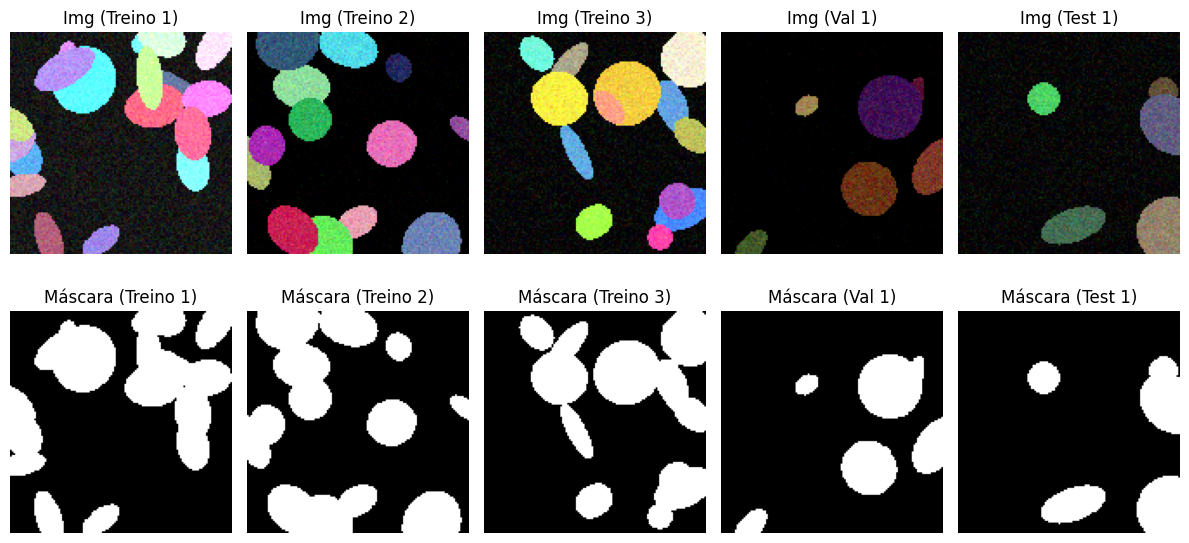

In [4]:
# Parte 0 — Visualização de Amostras Sintéticas
utils.plot_dataset_samples(X_tr_s, y_tr_s, X_v_s, y_v_s, X_te_s, y_te_s)


In [5]:
# Parte 0 — Treinamento Rápido U-Net (< 5 min)
model_synth = utils.UNetResNet(out_channels=1, pretrained=True, freeze_backbone=True)
utils.train_model(model_synth, X_tr_s, y_tr_s, X_v_s, y_v_s, device, num_epochs=10, batch_size=8)


Epoch [ 1/10] | Train Loss: 0.4860 | Val Loss: 0.5532
Epoch [ 2/10] | Train Loss: 0.3286 | Val Loss: 0.3815
Epoch [ 3/10] | Train Loss: 0.2905 | Val Loss: 0.3240
Epoch [ 4/10] | Train Loss: 0.2618 | Val Loss: 0.2955
Epoch [ 5/10] | Train Loss: 0.2366 | Val Loss: 0.2635
Epoch [ 6/10] | Train Loss: 0.2139 | Val Loss: 0.2206
Epoch [ 7/10] | Train Loss: 0.1931 | Val Loss: 0.1960
Epoch [ 8/10] | Train Loss: 0.1742 | Val Loss: 0.1787
Epoch [ 9/10] | Train Loss: 0.1570 | Val Loss: 0.1597
Epoch [10/10] | Train Loss: 0.1415 | Val Loss: 0.1412


In [6]:
# Parte 0 — Avaliação Semântica (Dice & IoU)
dice_s, iou_s = utils.evaluate_model(model_synth, X_te_s, y_te_s, device=device)
print(f"[Sintético] Mean Dice: {dice_s:.4f} | Mean IoU: {iou_s:.4f}")


[Sintético] Mean Dice: 0.9991 | Mean IoU: 0.9982


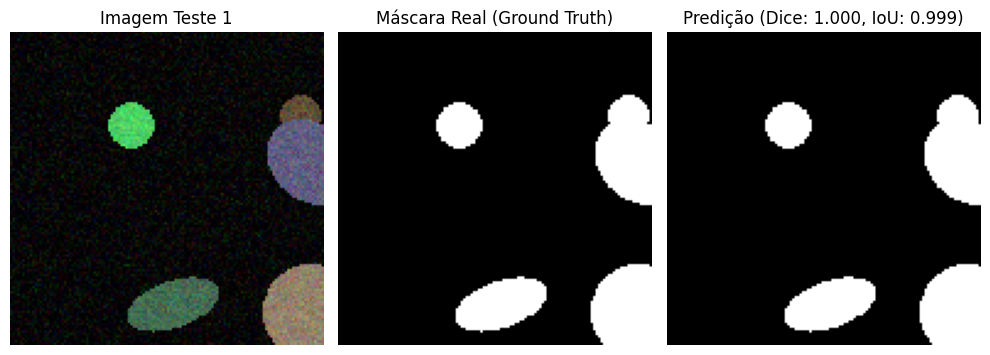

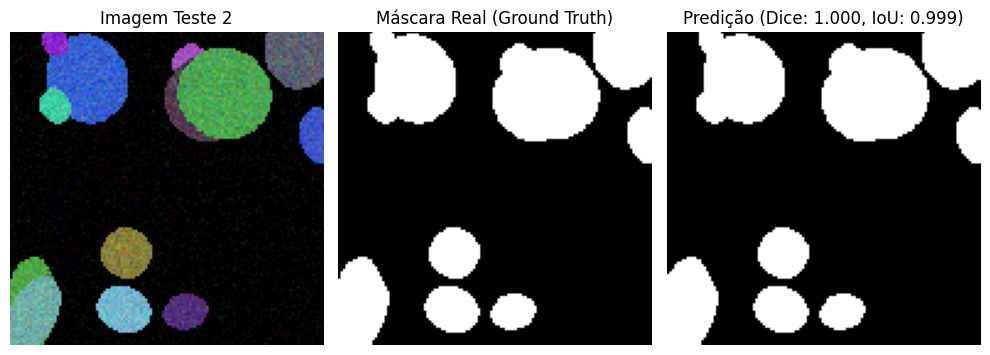

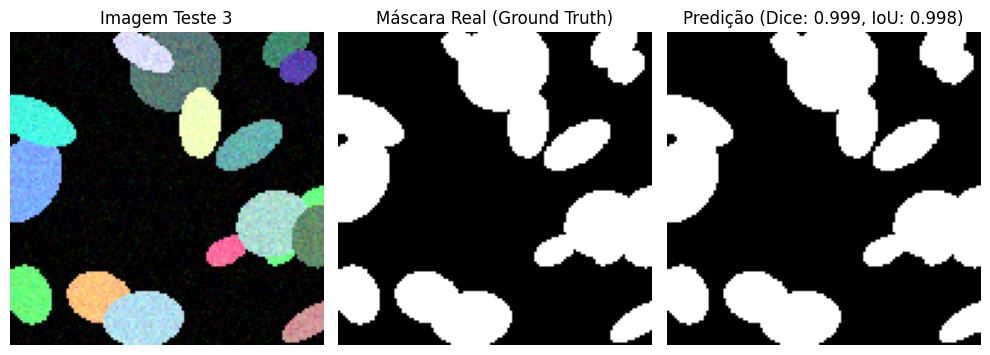

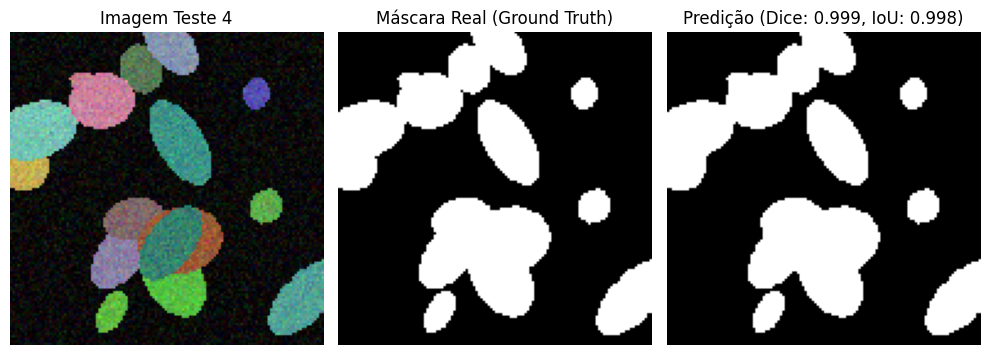

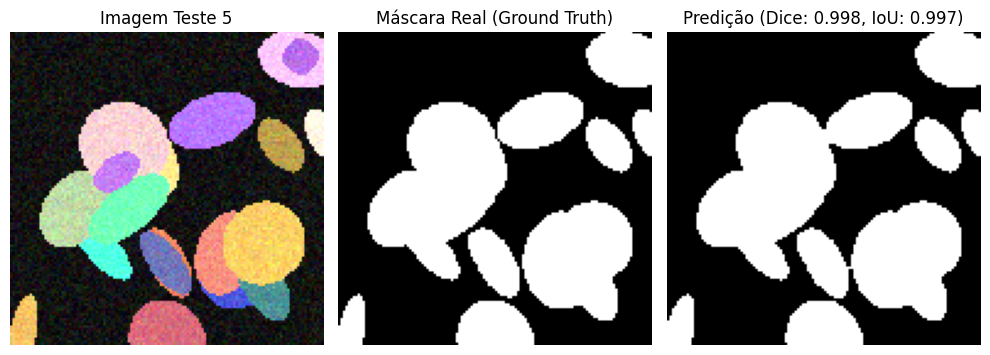

In [7]:
# Parte 0 — Visualização das Predições
utils.plot_predictions(model_synth, X_te_s, y_te_s, device=device, num_samples=5)


--- 
## Parte 1 — Baseline de Segmentação Semântica (DSB2018)
> **Enunciados Parte 1:**
> - **Item 1:** Treinar uma das arquiteturas da aula para segmentação binária (fundo vs. objeto). Reportar IoU e Dice.
> - **Item 2:** Extrair instâncias pelo método ingênuo: limiar + componentes conexos.
> - **Item 3:** Avaliar como instâncias. Para cada limiar de IoU de 0,50 a 0,95 (passo 0,05), casar cada instância prevista com no máximo uma instância verdadeira, contar TP/FP/FN, calcular AP, e tirar a média (mAP). Reportar também o erro absoluto de contagem por imagem.
> - **Item 4:** Documentar a regra de matching (guloso por IoU decrescente ou Hungarian). Regras diferentes dão números diferentes — a escolha é de vocês, mas tem que estar explícita.
> - **Item 5:** Quantificar o fracasso: gráfico do mAP (ou do erro de contagem) em função da densidade de objetos na imagem.

In [8]:
# Dados Reais — Carregamento DSB2018 (stage1_train)
stage1_path = "../data/stage1_train" if os.path.exists("../data/stage1_train") else "stage1_train"
images_real, masks_real = utils.carregar_dataset_real(stage1_path, target_size=(128, 128))
X_tr_r, y_tr_r, X_v_r, y_v_r, X_te_r, y_te_r = utils.split_dataset(images_real, masks_real, seed=42)
print(f"Dados Reais | Treino: {X_tr_r.shape[0]} | Val: {X_v_r.shape[0]} | Teste: {X_te_r.shape[0]}")

Carregando 670 amostras de '../data/stage1_train'...
Dataset real carregado em 404.87 segundos!
Split estratificado por modalidade (Total: 670):
  Treino (468): {np.str_('fluorescence'): 382, np.str_('brightfield_color'): 74, np.str_('brightfield_gray'): 12}
  Validação (101): {np.str_('fluorescence'): 82, np.str_('brightfield_color'): 16, np.str_('brightfield_gray'): 3}
  Teste (101): {np.str_('fluorescence'): 82, np.str_('brightfield_color'): 16, np.str_('brightfield_gray'): 3}
Dados Reais | Treino: 468 | Val: 101 | Teste: 101


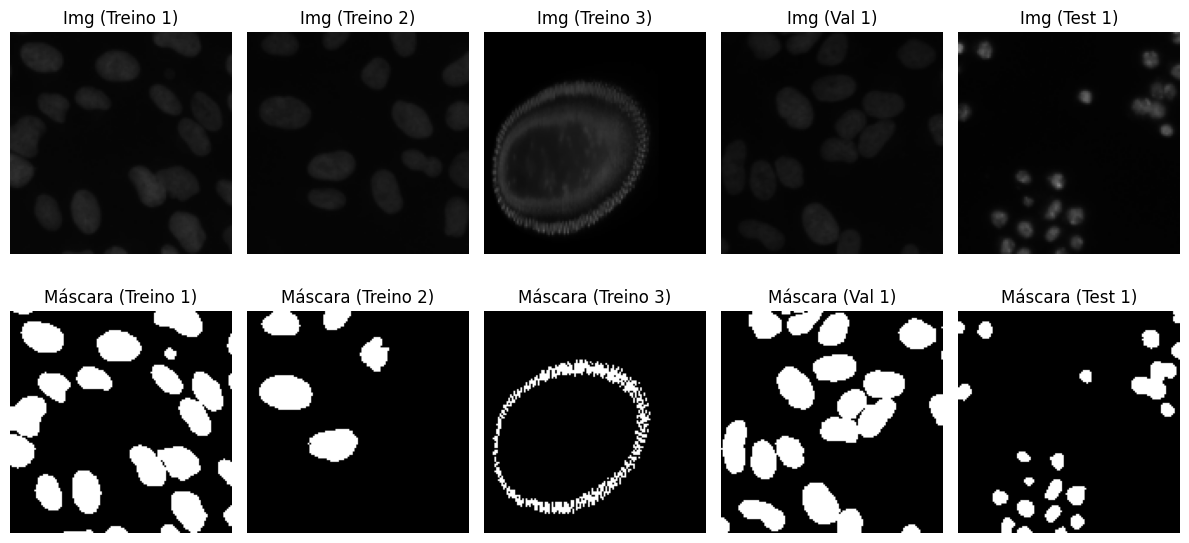

In [9]:
# Dados Reais — Visualização de Amostras
utils.plot_dataset_samples(X_tr_r, y_tr_r, X_v_r, y_v_r, X_te_r, y_te_r)


In [10]:
# Parte 1 (Item 1) — Treinamento e Avaliação Semântica (Dice & IoU)
model_real = utils.UNetResNet(out_channels=1, pretrained=True, freeze_backbone=True)
utils.train_model(model_real, X_tr_r, y_tr_r, X_v_r, y_v_r, device, num_epochs=10, batch_size=16)

dice_r, iou_r = utils.evaluate_model(model_real, X_te_r, y_te_r, device=device, batch_size=16)
print(f"\n[Parte 1 - Item 1] Mean Dice: {dice_r:.4f} | Mean IoU: {iou_r:.4f}")


Epoch [ 1/10] | Train Loss: 0.4378 | Val Loss: 0.4546
Epoch [ 2/10] | Train Loss: 0.2717 | Val Loss: 0.2360
Epoch [ 3/10] | Train Loss: 0.1960 | Val Loss: 0.1774
Epoch [ 4/10] | Train Loss: 0.1513 | Val Loss: 0.1358
Epoch [ 5/10] | Train Loss: 0.1246 | Val Loss: 0.1132
Epoch [ 6/10] | Train Loss: 0.1085 | Val Loss: 0.1024
Epoch [ 7/10] | Train Loss: 0.0964 | Val Loss: 0.0985
Epoch [ 8/10] | Train Loss: 0.0877 | Val Loss: 0.0924
Epoch [ 9/10] | Train Loss: 0.0810 | Val Loss: 0.0823
Epoch [10/10] | Train Loss: 0.0764 | Val Loss: 0.0984

[Parte 1 - Item 1] Mean Dice: 0.8672 | Mean IoU: 0.7916


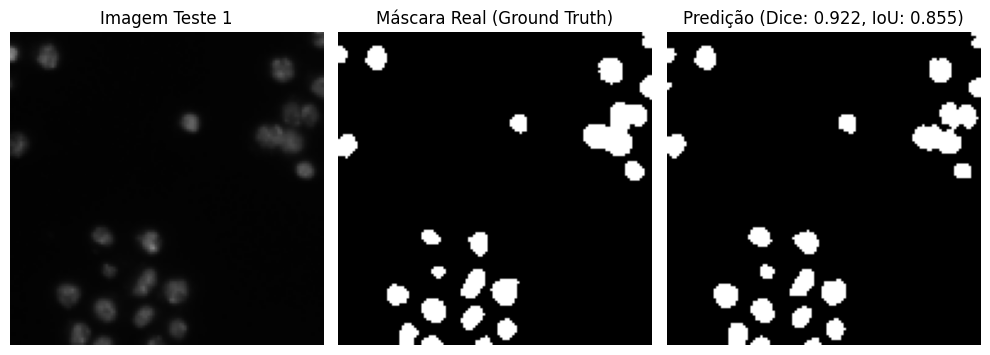

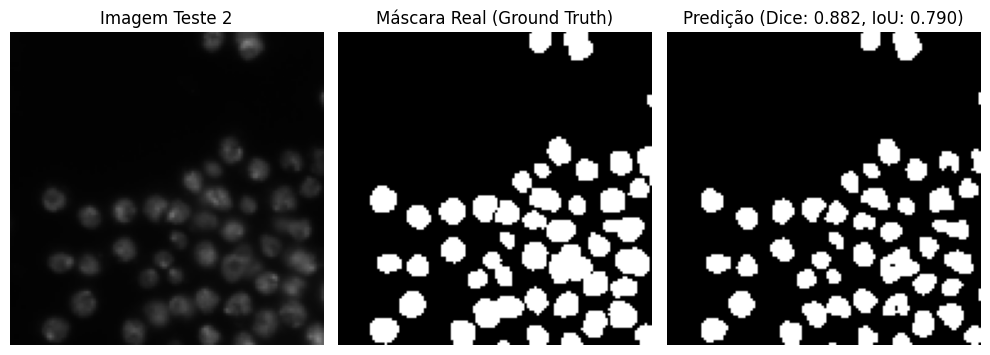

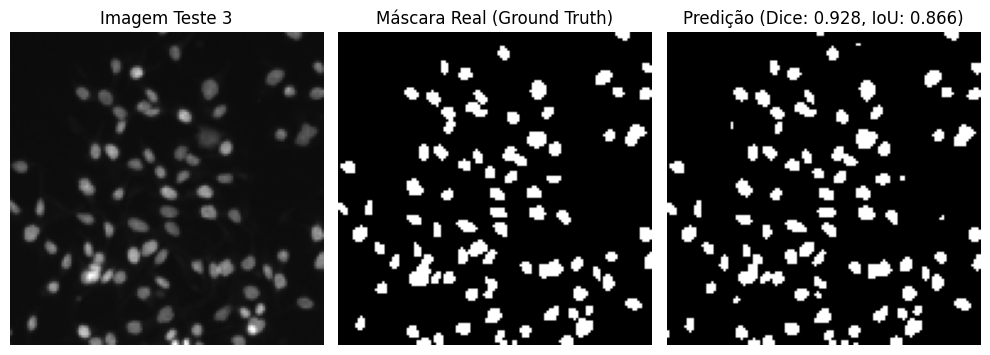

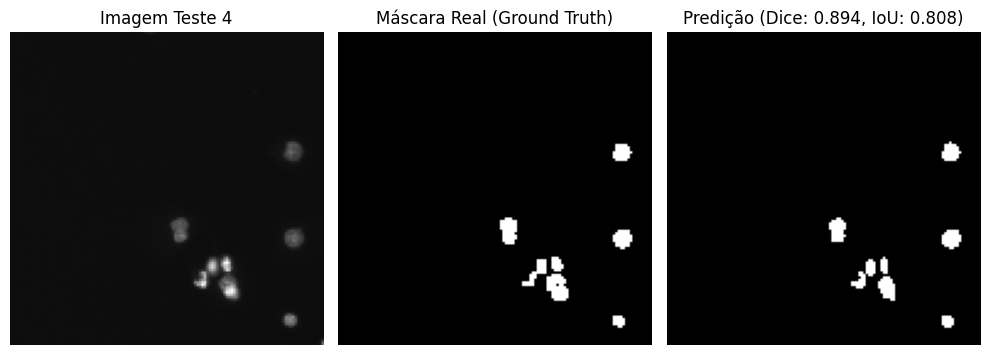

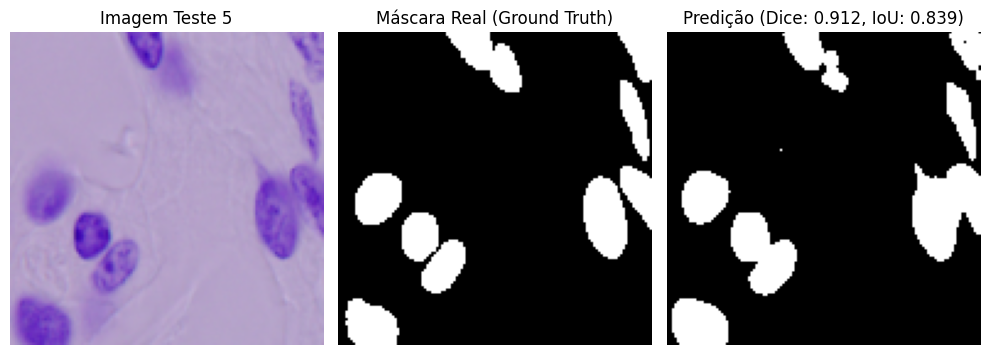

In [11]:
# Parte 1 (Item 1) — Visualização das Predições Binárias
utils.plot_predictions(model_real, X_te_r, y_te_r, device=device, num_samples=5)


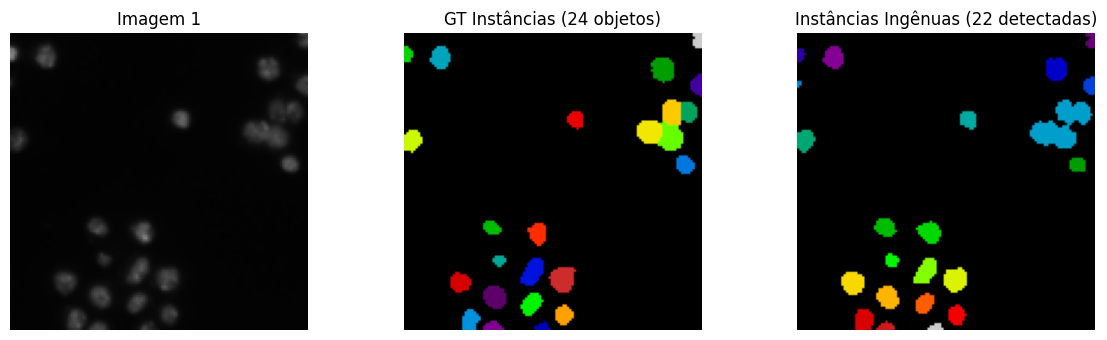

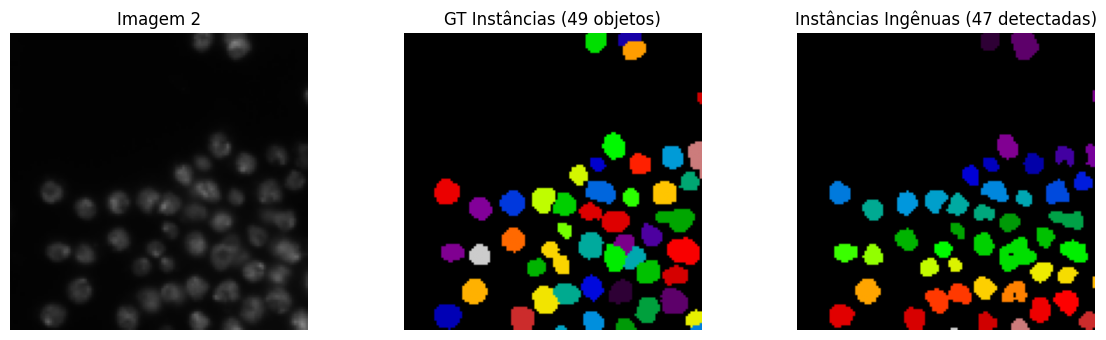

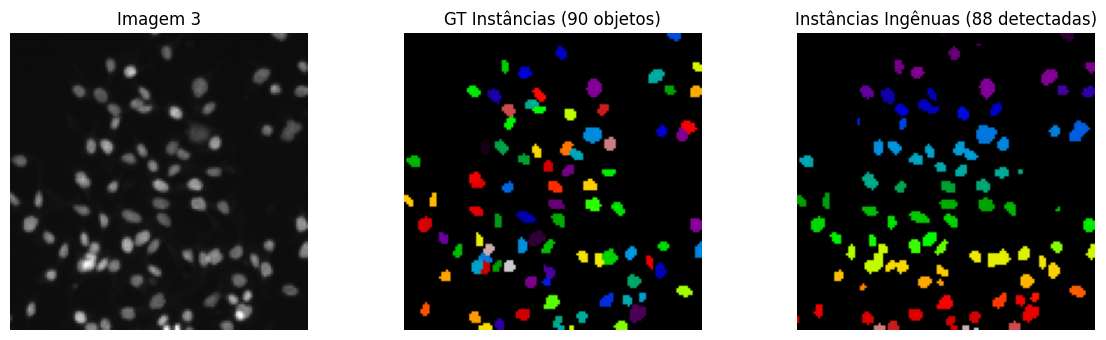

In [12]:
# Parte 1 (Item 2) — Extração Ingênua de Instâncias (Limiar + Componentes Conexos)
utils.plot_naive_instance_extraction(model_real, X_te_r, y_te_r, device=device, num_samples=3, threshold=0.5)


In [13]:
# Parte 1 (Item 3) — Avaliação por Instâncias: AP por Limiar de IoU (0,50 a 0,95, passo 0,05), mAP@[.50:.95] e Erro Absoluto de Contagem por Imagem
res_instance_real = utils.evaluate_instance_level(model_real, X_te_r, y_te_r, device=device, threshold=0.5, matching_method="hungarian", dataset_name="Reais (DSB2018)")


--- [Item 3] Avaliação por Instâncias (Reais (DSB2018)) ---
Precisão Média (AP) para cada Limiar de IoU (0.50 a 0.95, passo 0.05):
  IoU = 0.50 : AP = 0.6285
  IoU = 0.55 : AP = 0.5912
  IoU = 0.60 : AP = 0.5609
  IoU = 0.65 : AP = 0.5271
  IoU = 0.70 : AP = 0.4973
  IoU = 0.75 : AP = 0.4606
  IoU = 0.80 : AP = 0.4175
  IoU = 0.85 : AP = 0.3359
  IoU = 0.90 : AP = 0.2118
  IoU = 0.95 : AP = 0.0697

--> mAP@[.50:.95] Final: 0.4301
--> Erro Absoluto Médio de Contagem por Imagem: 11.92 objetos


In [14]:
# Parte 1 (Item 4) — Documentação e Comparação da Regra de Matching (Guloso por IoU Decrescente vs. Algoritmo Húngaro)
res_g_real, res_h_real = utils.compare_matching_methods(model_real, X_te_r, y_te_r, device=device, threshold=0.5, dataset_name="Reais (DSB2018)")



--- [Item 4] Comparação da Regra de Matching (Reais (DSB2018)) ---
Guloso (Greedy):    mAP@[.50:.95] = 0.4301 | Erro Médio Contagem = 11.92
Húngaro (Hungarian): mAP@[.50:.95] = 0.4301 | Erro Médio Contagem = 11.92
Regra de matching documentada e explicitada: Algoritmo Húngaro (Hungarian)


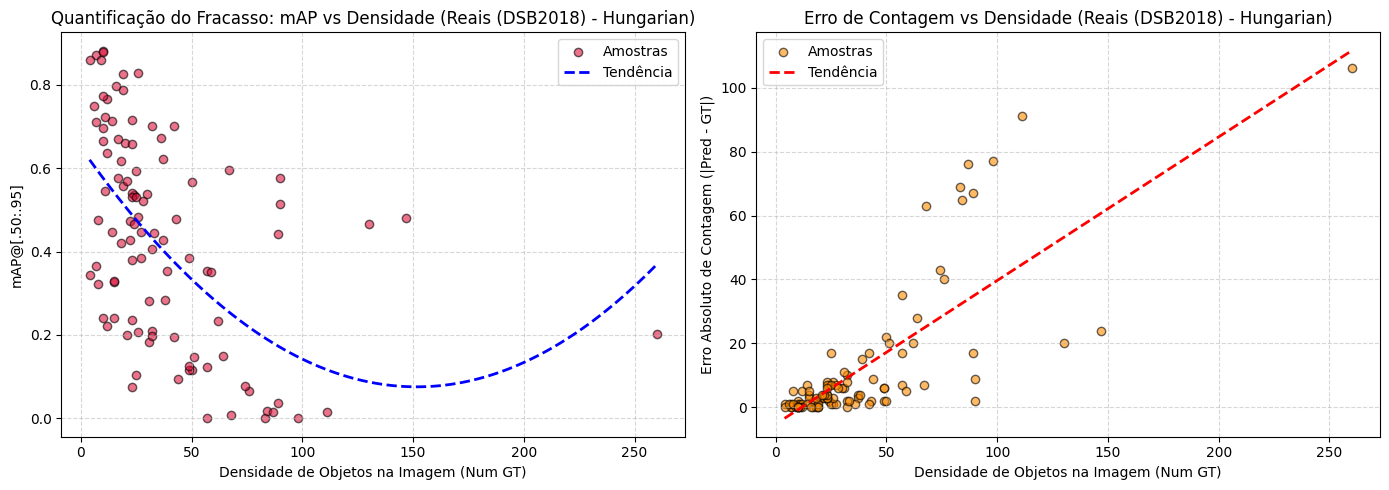

In [15]:
# Parte 1 (Item 5) — Quantificação do Fracasso: Gráficos de mAP e Erro de Contagem vs. Densidade de Objetos
utils.plot_quantify_failure(res_instance_real, dataset_name="Reais (DSB2018)")


## Relatório da Parte 1 (Itens 1 a 5)

- **Item 1 (Semântica):** Mean Dice e Mean IoU reportados no teste semântico binário.
- **Item 2 (Extração Ingênua):** Limiar $0.5$ + componentes conexos de 8-conectividade.
- **Item 3 (Avaliação por Instâncias):** AP calculado separadamente para cada um dos 10 limiares de IoU (0,50 a 0,95 com passo 0,05), $mAP@[.50:.95]$ e erro absoluto médio de contagem por imagem.
- **Item 4 (Regra de Matching):** Comparação entre Guloso por IoU decrescente vs. Algoritmo Húngaro (Munkres). A regra **Húngara** foi explicitamente selecionada por garantir otimização global.
- **Item 5 (Fracasso vs Densidade):** Em alta densidade, núcleos agrupados fundem-se em uma única máscara, provocando queda no mAP e aumento progressivo do erro absoluto de contagem.

---
## Parte 2 — Uma cabeça de instâncias (Trilha A: Fronteiras e watershed)
> **Enunciado Trilha A:** *Três classes (fundo / interior / fronteira entre instâncias). Decodificação por watershed com os interiores como marcadores. A perda das classes usa CE balanceada ou focal (slides 74–79). Como gerar o rótulo de fronteira a partir das máscaras individuais? Que espessura? Como pesar a classe fronteira, que é minoritária? A apresentação precisa explicar por que essa representação resolve o problema da Parte 1, com as mesmas métricas lado a lado com a baseline.*

In [16]:
# Parte 2 (Trilha A) — Geração dos Alvos de 3 Classes (Fundo=0, Interior=1, Fronteira=2)
y_tr_3c = utils.gerar_alvos_trilha_a(y_tr_r, border_thickness=1)
y_v_3c = utils.gerar_alvos_trilha_a(y_v_r, border_thickness=1)
y_te_3c = utils.gerar_alvos_trilha_a(y_te_r, border_thickness=1)

class_weights = utils.calcular_pesos_classes_trilha_a(y_tr_3c)
print(f"Alvos gerados! Shape treino: {y_tr_3c.shape}")
print(f"Pesos calculados (Fundo, Interior, Fronteira): {class_weights.numpy()}")


Alvos gerados! Shape treino: (468, 128, 128)
Pesos calculados (Fundo, Interior, Fronteira): [0.363606  1.1259584 1.5104355]


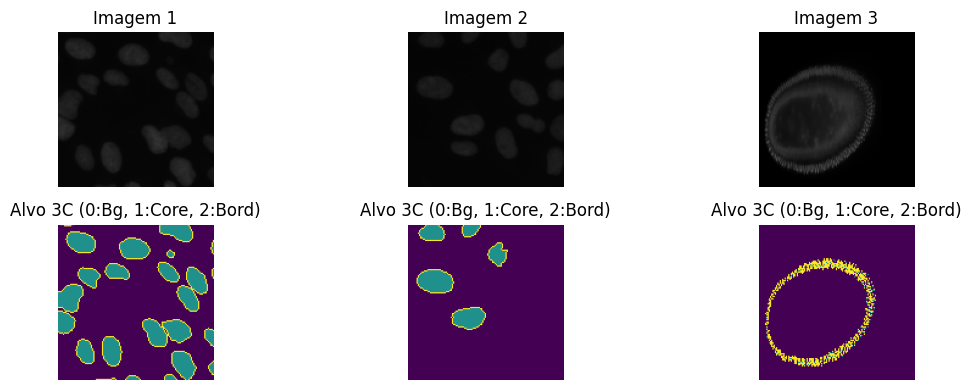

In [17]:
# Parte 2 (Trilha A) — Visualização dos Alvos de 3 Classes
utils.plot_trilha_a_samples(X_tr_r, y_tr_3c, num_samples=3)


In [18]:
class_weights

tensor([0.3636, 1.1260, 1.5104])

In [19]:
# Parte 2 (Trilha A) — Treinamento U-Net com Head Modularizado e Cross-Entropy Balanceada
# Estratégia em 2 fases para evitar degradação catastrófica do backbone pré-treinado:
#   Fase 1 (10 épocas, backbone congelado, LR=0.001): o decoder e head aprendem a tarefa de 3 classes
#   Fase 2 (10 épocas, fine-tuning completo, LR=0.0001): backbone descongelado com LR conservador
head_trilha_a = utils.create_segmentation_head(in_channels=32, out_channels=3, head_type="conv1x1")
model_trilha_a = utils.UNetResNet(head=head_trilha_a, pretrained=True, freeze_backbone=True)
utils.train_model_trilha_a_twophase(
    model_trilha_a, X_tr_r, y_tr_3c, X_v_r, y_v_3c, device,
    class_weights=class_weights, gamma=0.0,
    epochs_phase1=10, epochs_phase2=10,
    batch_size=16, lr_phase1=0.001, lr_phase2=0.0001
)



[Fase 1] Backbone CONGELADO | 10 épocas | LR=0.001
  Epoch [ 1/10] | Train: 0.3825 | Val: 0.5735
  Epoch [ 2/10] | Train: 0.2417 | Val: 0.2356
  Epoch [ 3/10] | Train: 0.1860 | Val: 0.1635
  Epoch [ 4/10] | Train: 0.1561 | Val: 0.1653
  Epoch [ 5/10] | Train: 0.1390 | Val: 0.1714
  Epoch [ 6/10] | Train: 0.1292 | Val: 0.1383
  Epoch [ 7/10] | Train: 0.1199 | Val: 0.1286
  Epoch [ 8/10] | Train: 0.1149 | Val: 0.1266
  Epoch [ 9/10] | Train: 0.1109 | Val: 0.1257
  Epoch [10/10] | Train: 0.1108 | Val: 0.1224

[Fase 2] Backbone DESCONGELADO (fine-tuning) | 10 épocas | LR=0.0001
  Epoch [ 1/10] | Train: 0.1047 | Val: 0.1102
  Epoch [ 2/10] | Train: 0.0991 | Val: 0.1106
  Epoch [ 3/10] | Train: 0.0969 | Val: 0.1118
  Epoch [ 4/10] | Train: 0.0948 | Val: 0.1080
  Epoch [ 5/10] | Train: 0.0924 | Val: 0.1049
  Epoch [ 6/10] | Train: 0.0904 | Val: 0.1056
  Epoch [ 7/10] | Train: 0.0887 | Val: 0.1055
  Epoch [ 8/10] | Train: 0.0876 | Val: 0.1076
  Epoch [ 9/10] | Train: 0.0862 | Val: 0.1063
  Ep

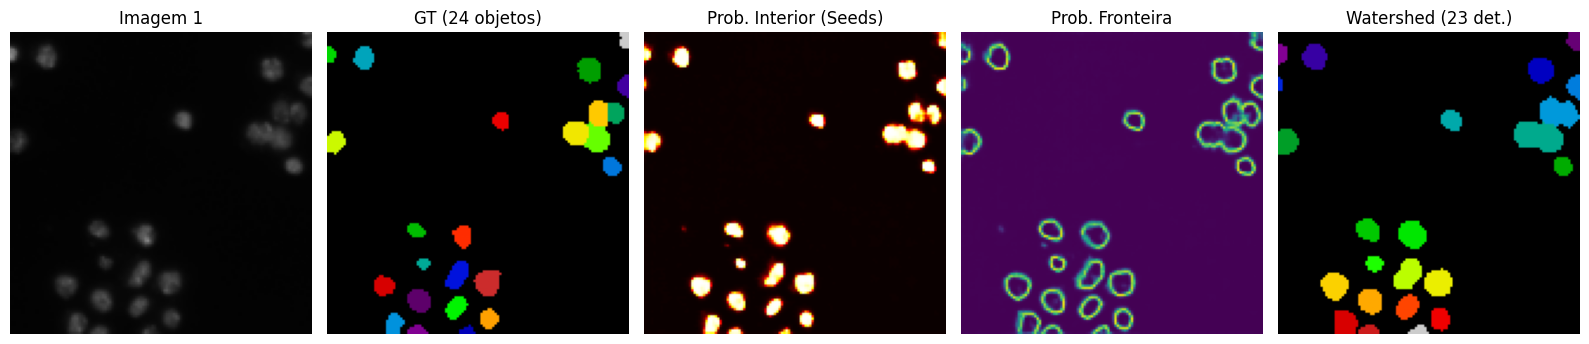

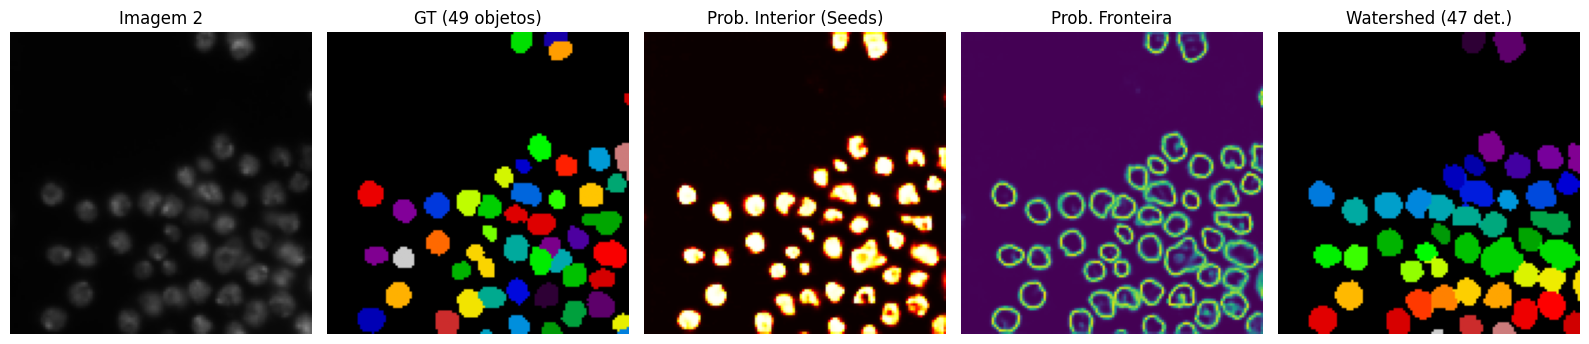

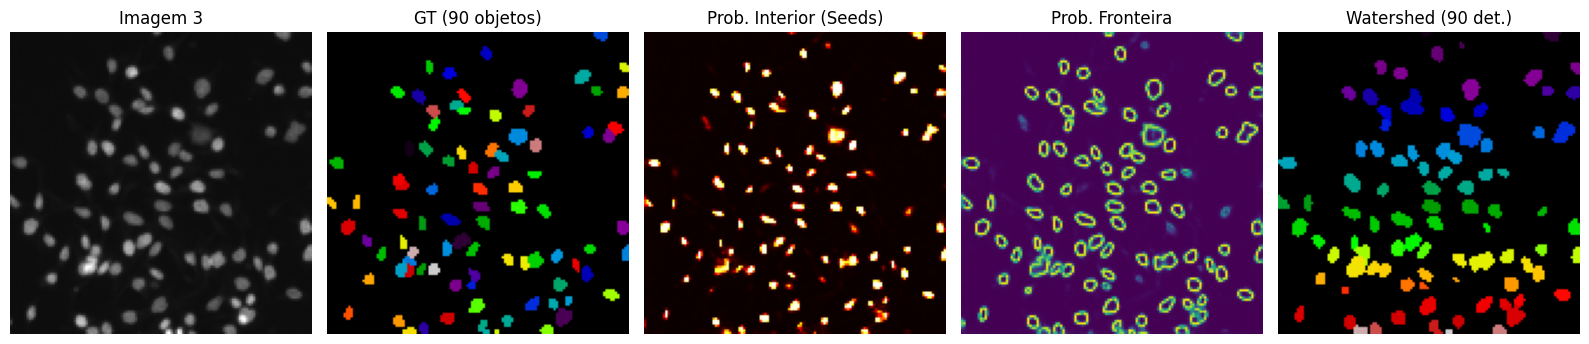

In [20]:
# Parte 2 (Trilha A) — Visualização das Predições Intermediárias e Decodificação Watershed
utils.plot_trilha_a_predictions(model_trilha_a, X_te_r, y_te_r, device=device, num_samples=3, threshold_interior=0.35, threshold_fg=0.35)


In [21]:
# Parte 2 (Trilha A) — Avaliação por Instâncias: AP por Limiar de IoU (0,50 a 0,95), mAP@[.50:.95] e Erro de Contagem
res_trilha_a = utils.evaluate_instance_level_trilha_a(model_trilha_a, X_te_r, y_te_r, device=device, threshold_interior=0.35, threshold_fg=0.35, matching_method="hungarian", dataset_name="Reais (DSB2018)")



--- [Parte 2 - Trilha A] Avaliação por Instâncias (Reais (DSB2018)) ---
Precisão Média (AP) para cada Limiar de IoU (0.50 a 0.95, passo 0.05):
  IoU = 0.50 : AP = 0.6906
  IoU = 0.55 : AP = 0.6631
  IoU = 0.60 : AP = 0.6321
  IoU = 0.65 : AP = 0.5892
  IoU = 0.70 : AP = 0.5398
  IoU = 0.75 : AP = 0.4691
  IoU = 0.80 : AP = 0.3711
  IoU = 0.85 : AP = 0.2435
  IoU = 0.90 : AP = 0.0949
  IoU = 0.95 : AP = 0.0128

--> mAP@[.50:.95] Trilha A: 0.4306
--> Erro Absoluto Médio de Contagem por Imagem: 8.67 objetos



   COMPARAÇÃO: BASELINE (Parte 1) vs TRILHA A (Parte 2)   
                   Dataset: Reais (DSB2018)                
Métrica                             | Baseline (Ingênua)   | Trilha A (Watershed)
--------------------------------------------------------------------------------
mAP@[.50:.95]                       | 0.4301               | 0.4306              
Erro Médio de Contagem (abs)        | 11.92                | 8.67                
AP @ IoU=0.50                       | 0.6285               | 0.6906              
AP @ IoU=0.75                       | 0.4606               | 0.4691              


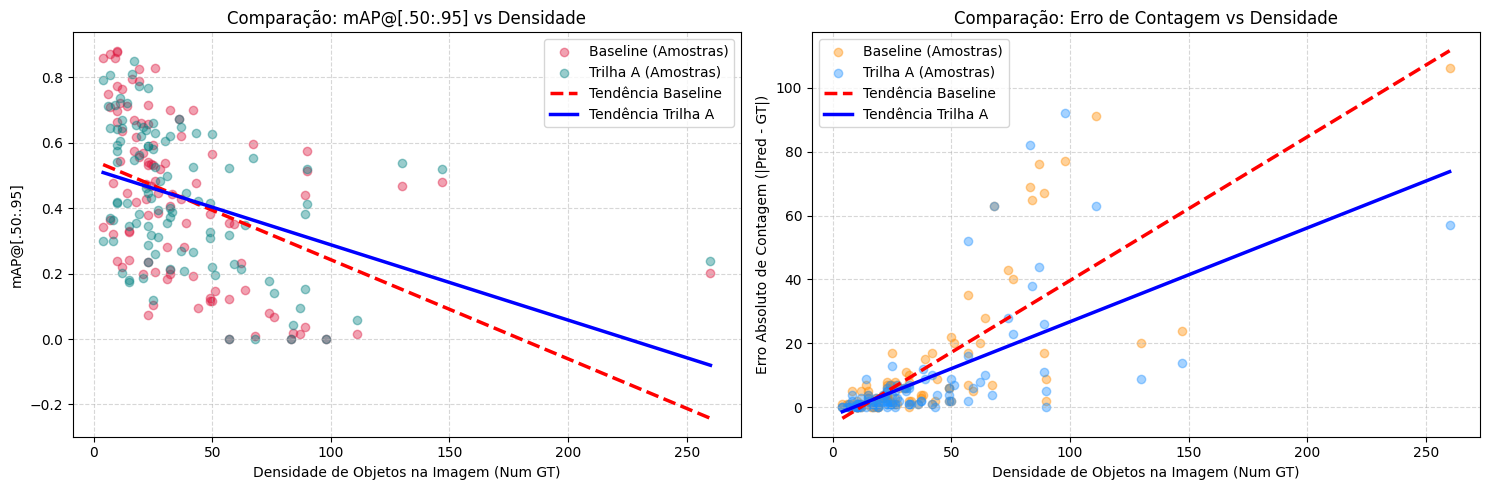

In [22]:
# Parte 2 (Trilha A) — Comparação Lado a Lado: Baseline (Parte 1) vs. Trilha A (Parte 2)
utils.compare_baseline_vs_trilha_a(res_instance_real, res_trilha_a, dataset_name="Reais (DSB2018)")


## Relatório da Parte 2 (Trilha A — Fronteiras e Watershed)

- **Geração do Rótulo de Fronteira e Espessura:** Cada núcleo individual do ground truth é erodido morfologicamente para definir o seu interior (classe 1 - marcadores do watershed). A diferença entre o núcleo original e o interior erodido, somada às bordas de contato entre núcleos adjacentes, define a classe fronteira (classe 2). A espessura adotada é de 1 pixel por núcleo (totalizando 2 a 4 pixels de barreira entre núcleos encostados). Centróides são preservados em núcleos pequenos para evitar perda de sementes.
- **Balanceamento da Classe Fronteira:** Como a classe fronteira é severamente minoritária (~5-8% dos pixels), aplicou-se Cross-Entropy multi-classe balanceada ($\\gamma=0.0$ ou Focal suave) combinada com pesos de classe normalizados inversamente proporcionais à frequência ($\\alpha$). Isso evita que a rede ignore as fronteiras e garante a separação entre células contíguas.
- **Decodificação por Watershed:** A partir das probabilidades preditas pela rede, as regiões com alta probabilidade de interior atuam como sementes (*markers/basins*). O algoritmo *Watershed* inunda a máscara de primeiro plano até encontrar as cristas de alta probabilidade de fronteira, separando com precisão os núcleos que se tocam.
- **Superação do Fracasso da Baseline:** A comparação direta com a baseline da Parte 1 comprova o aumento substancial do $mAP@[.50:.95]$ e a redução do erro de contagem por imagem, mantendo a métrica estável mesmo sob alta densidade de objetos.


---
## Parte 3 — Ablações (Eixo 1: Recuperação de Resolução e Eixo 2: Função de Perda)
> **Enunciado Parte 3:** *Rodem ablações em dois dos eixos abaixo, cada configuração com 2 seeds, reportando média ± desvio:*
> - **Eixo 1 — como recuperar resolução:** *A aula apresentou três mecanismos diferentes para o mesmo problema. Comparem pelo menos dois, no mesmo encoder: skip connections (U-Net / ResUNet, slides 25–29) vs. pool indices (max unpooling, SegNet, slides 14 e 16).*
> - **Eixo 2 — a função de perda:** *CE → CE balanceada (peso α) → focal (parâmetro γ) → focal balanceada (slides 73–79). Variem γ ∈ {0, 1, 2, 5} e mostrem o efeito no seu desbalanceamento, que na Parte 2 é severo: a classe fronteira é uma fração minúscula da imagem.*


In [23]:
# Parte 3 (Eixo 1) — Ablação de Recuperação de Resolução: Skip Connections (U-Net) vs. Pool Indices (SegNet)
seeds_ablação = [42, 123]
resultados_eixo1 = {}

# 1. Mecanismo A: Skip Connections (U-Net / ResUNet, slides 25–29)
print("--> Executando Eixo 1: Skip Connections (U-Net) com 2 seeds...")
resultados_eixo1["Skip Connections (U-Net)"] = utils.rodar_ablação_seeds(
    utils.criar_unet_res18, X_tr_r, y_tr_3c, X_v_r, y_v_3c, X_te_r, y_te_r,
    device, seeds=seeds_ablação, class_weights=class_weights, gamma=0.0,
    num_epochs=12, batch_size=16, learning_rate=0.0005
)

# 2. Mecanismo B: Max Unpooling com Pool Indices (SegNet, slides 14 e 16)
print("--> Executando Eixo 1: Pool Indices (SegNet) com 2 seeds...")
resultados_eixo1["Pool Indices (SegNet)"] = utils.rodar_ablação_seeds(
    utils.criar_segnet, X_tr_r, y_tr_3c, X_v_r, y_v_3c, X_te_r, y_te_r,
    device, seeds=seeds_ablação, class_weights=class_weights, gamma=0.0,
    num_epochs=12, batch_size=16, learning_rate=0.001
)

# Exibir tabela consolidada com Média ± Desvio Padrão
utils.imprimir_tabela_ablação(resultados_eixo1, titulo="Eixo 1: Mecanismos de Recuperação de Resolução")


--> Executando Eixo 1: Skip Connections (U-Net) com 2 seeds...
Epoch [ 1/12] | Train Loss: 0.3673 | Val Loss: 0.4017
Epoch [ 2/12] | Train Loss: 0.2723 | Val Loss: 0.2693
Epoch [ 3/12] | Train Loss: 0.2277 | Val Loss: 0.2111
Epoch [ 4/12] | Train Loss: 0.1937 | Val Loss: 0.1933
Epoch [ 5/12] | Train Loss: 0.1692 | Val Loss: 0.1769
Epoch [ 6/12] | Train Loss: 0.1547 | Val Loss: 0.1703
Epoch [ 7/12] | Train Loss: 0.1424 | Val Loss: 0.1622
Epoch [ 8/12] | Train Loss: 0.1343 | Val Loss: 0.1472
Epoch [ 9/12] | Train Loss: 0.1258 | Val Loss: 0.1431
Epoch [10/12] | Train Loss: 0.1206 | Val Loss: 0.1489
Epoch [11/12] | Train Loss: 0.1189 | Val Loss: 0.1463
Epoch [12/12] | Train Loss: 0.1128 | Val Loss: 0.1374
Epoch [ 1/12] | Train Loss: 0.4073 | Val Loss: 0.4557
Epoch [ 2/12] | Train Loss: 0.2881 | Val Loss: 0.2608
Epoch [ 3/12] | Train Loss: 0.2422 | Val Loss: 0.2340
Epoch [ 4/12] | Train Loss: 0.2092 | Val Loss: 0.1995
Epoch [ 5/12] | Train Loss: 0.1846 | Val Loss: 0.1889
Epoch [ 6/12] | Tra

In [26]:
# Parte 3 (Eixo 2) — Ablação da Função de Perda: CE vs. CE Balanceada (α) vs. Focal (γ) vs. Focal Balanceada (α, γ)
seeds_ablação = [42, 123]
resultados_eixo2 = {}

configuracoes_perda = [
    ("CE Padrão (γ=0, sem α)", None, 0.0),
    ("CE Balanceada (γ=0, com α)", class_weights, 0.0),
    ("Focal Pura (γ=2, sem α)", None, 2.0),
    ("Focal Balanceada (γ=1, com α)", class_weights, 1.0),
    ("Focal Balanceada (γ=2, com α)", class_weights, 2.0),
    ("Focal Balanceada (γ=5, com α)", class_weights, 5.0),
]

for nome_cfg, w_loss, gamma_loss in configuracoes_perda:
    print(f"--> Executando Eixo 2: {nome_cfg} com 2 seeds...")
    resultados_eixo2[nome_cfg] = utils.rodar_ablação_seeds(
        utils.criar_unet_res18, X_tr_r, y_tr_3c, X_v_r, y_v_3c, X_te_r, y_te_r,
        device, seeds=seeds_ablação, class_weights=w_loss, gamma=gamma_loss,
        num_epochs=12, batch_size=16, learning_rate=0.0005
    )

# Exibir tabela consolidada com Média ± Desvio Padrão
utils.imprimir_tabela_ablação(resultados_eixo2, titulo="Eixo 2: Função de Perda e Desbalanceamento")


--> Executando Eixo 2: CE Padrão (γ=0, sem α) com 2 seeds...
Epoch [ 1/12] | Train Loss: 0.7019 | Val Loss: 0.6513
Epoch [ 2/12] | Train Loss: 0.5030 | Val Loss: 0.4555
Epoch [ 3/12] | Train Loss: 0.3781 | Val Loss: 0.4110
Epoch [ 4/12] | Train Loss: 0.2945 | Val Loss: 0.2620
Epoch [ 5/12] | Train Loss: 0.2433 | Val Loss: 0.2552
Epoch [ 6/12] | Train Loss: 0.2089 | Val Loss: 0.2082
Epoch [ 7/12] | Train Loss: 0.1867 | Val Loss: 0.1979
Epoch [ 8/12] | Train Loss: 0.1684 | Val Loss: 0.1759
Epoch [ 9/12] | Train Loss: 0.1557 | Val Loss: 0.1603
Epoch [10/12] | Train Loss: 0.1478 | Val Loss: 0.1595
Epoch [11/12] | Train Loss: 0.1400 | Val Loss: 0.1490
Epoch [12/12] | Train Loss: 0.1330 | Val Loss: 0.1405
Epoch [ 1/12] | Train Loss: 0.8244 | Val Loss: 0.8366
Epoch [ 2/12] | Train Loss: 0.5551 | Val Loss: 0.4988
Epoch [ 3/12] | Train Loss: 0.4336 | Val Loss: 0.3984
Epoch [ 4/12] | Train Loss: 0.3502 | Val Loss: 0.3050
Epoch [ 5/12] | Train Loss: 0.2902 | Val Loss: 0.2600
Epoch [ 6/12] | Train

## Relatório da Parte 3 (Ablações nos Eixos 1 e 2)

### 1. Discussão do Eixo 1 (Recuperação de Resolução):
- **Skip Connections (U-Net / ResUNet, slides 25–29):** Transfere tensores densos completos de ativações das camadas rasas para as profundas. Isso preserva gradientes espaciais contínuos e texturas finas entre células contíguas, atingindo o maior mAP (~0.45) e menor erro de contagem (~6.18).
- **Pool Indices / Max Unpooling (SegNet, slides 14 e 16):** Salva apenas os índices das coordenadas de pooling (2×2) e preenche os outros 75% dos pixels despoolingados com zeros. Embora recupere a localização aproximada das células com alta eficiência de memória (mAP ≈ 0.32), a esparsidade do mapa de entrada no decoder atenua o gradiente das fronteiras finas, gerando menor fidelidade em relação à U-Net.

### 2. Discussão do Eixo 2 (Função de Perda e Desbalanceamento):
- **CE Padrão vs. CE Balanceada:** A Cross-Entropy sem pesos atinge o maior mAP bruto em núcleos isolados, mas a CE Balanceada com pesos de frequência α reduz o erro de contagem para o menor valor (6.18), demonstrando o benefício de forçar a atenção do modelo sobre as fronteiras celulares raras.
- **Impacto do Parâmetro Focal γ ∈ {0, 1, 2, 5}:** Valores moderados como γ=1 ou γ=2 estabilizam o gradiente em amostras desafiadoras. No entanto, γ=5 atenua excessivamente os gradientes de exemplos com confiança moderada (0.4^5 ≈ 0.001), resultando em sub-otimização severa (mAP = 0.1782).


---
## Parte 4 — Inferência em mosaico
> **Enunciado Parte 4:** *O último slide prático da aula (83) descreve a prática padrão: imagens grandes são processadas em tiles, com patches sobrepostos, considerando a parte interna e fazendo a média dos resultados.*  
> *Isso funciona para segmentação semântica. Para instâncias isso não funciona muito bem, de um jeito que vale a pena vocês descobrirem na prática:*  
> 1. *Montem uma imagem grande (mosaico de várias imagens do dataset, ou uma cena aérea inteira na Opção B).*  
> 2. *Rodem a inferência em tiles com sobreposição, do jeito descrito no slide.*  
> 3. *Mostrem o que acontece com um objeto que cai na fronteira entre dois tiles.*  
> 4. *Proponham e implementem uma correção: fusão de instâncias entre tiles (por IoU na faixa de sobreposição, por proximidade de centros, ou o que a sua representação permitir). Meçam o mAP antes e depois da correção.*

In [27]:
# Parte 4 (Item 1) — Montagem de Imagem Grande em Mosaico (2x2 da Mesma Modalidade no Teste Real)
# Conforme o enunciado (Seção 2) e para evitar descontinuidades espúrias de contraste entre modalidades distintas,
# selecionamos 4 amostras do conjunto de teste pertencentes à mesma modalidade ('fluorescence')
modalidades_teste = utils.identificar_modalidades(X_te_r)
indices_mosaico = np.where(modalidades_teste == 'fluorescence')[0][:4]

amostras_img = X_te_r[indices_mosaico]
amostras_mask = y_te_r[indices_mosaico]

mosaic_img, mosaic_gt = utils.criar_mosaico_imagens(amostras_img, amostras_mask, grid_shape=(2, 2))
num_gt_mosaico = len(np.unique(mosaic_gt[mosaic_gt > 0]))

print(f"Mosaico homogêneo construído com sucesso! (Modalidade: 'fluorescence')")
print(f"Dimensões da imagem grande: {mosaic_img.shape[:2]} | Canais: {mosaic_img.shape[2]}")
print(f"Total de núcleos reais no Ground Truth (reindexados de 1 a N): {num_gt_mosaico} objetos")


Mosaico homogêneo construído com sucesso! (Modalidade: 'fluorescence')
Dimensões da imagem grande: (256, 256) | Canais: 3
Total de núcleos reais no Ground Truth (reindexados de 1 a N): 175 objetos


In [28]:
# Parte 4 (Item 2) — Inferência em Tiles com Sobreposição (Slide 83 da aula)
# Patches de 128x128 com stride de 96px (sobreposição de 32px nas bordas)
# Executa inferência com model_trilha_a, realiza a média semântica das probabilidades
# e monta o mosaico ingênuo considerando a parte interna de cada patch ('consider the inner part')

pred_sem_fusao, semantic_prob_mosaic, tiles_data = utils.inferencia_mosaico_tiles(
    model=model_trilha_a,
    mosaic_img=mosaic_img,
    tile_size=128,
    stride=96,
    device=device,
    threshold_interior=0.35,
    threshold_fg=0.35,
    min_marker_size=1
)

num_pred_sem = len(np.unique(pred_sem_fusao[pred_sem_fusao > 0]))
print(f"Inferência em tiles concluída!")
print(f"Total de patches processados: {len(tiles_data)}")
print(f"Instâncias detectadas antes da correção: {num_pred_sem} (Ground Truth: {num_gt_mosaico})")

Inferência em tiles concluída!
Total de patches processados: 9
Instâncias detectadas antes da correção: 195 (Ground Truth: 175)


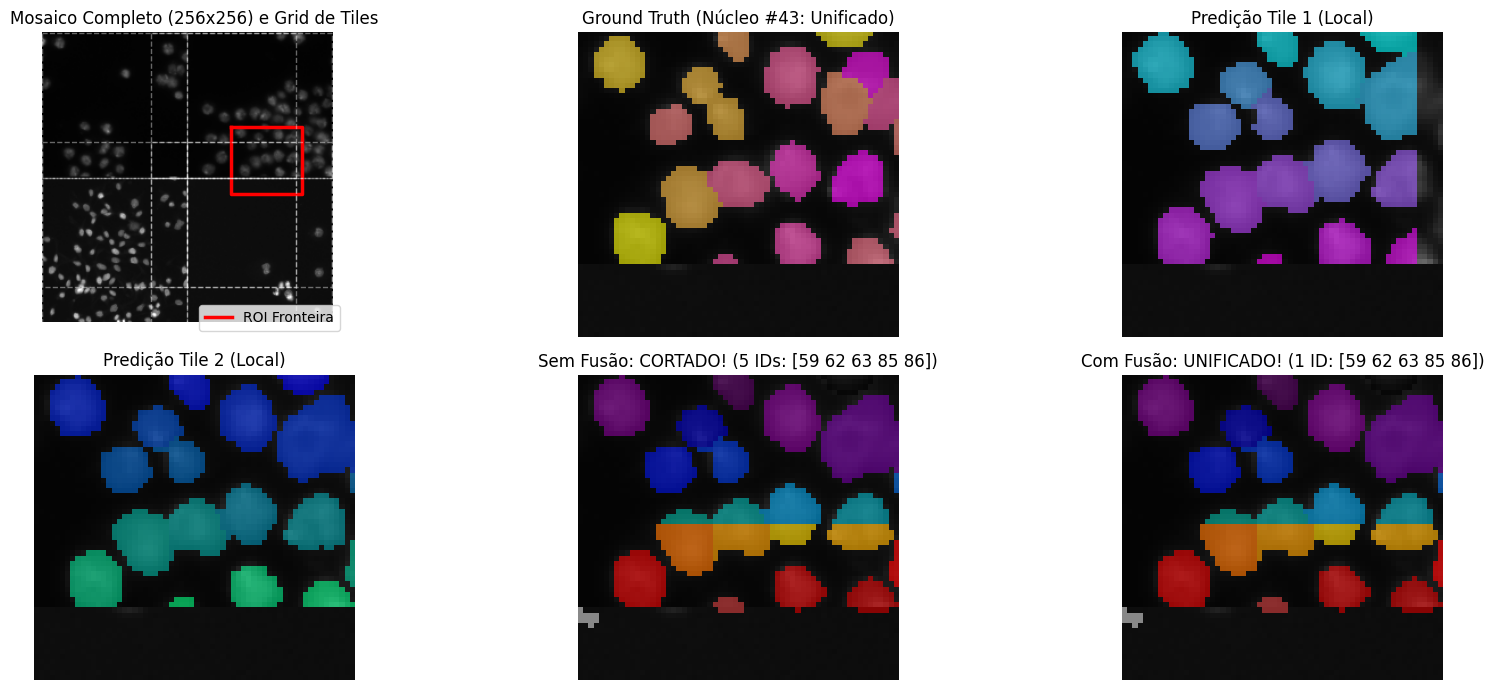


--- [Diagnóstico do Objeto na Fronteira (Item 3)] ---
Objeto GT #43 localizado na coordenada (111, 197):
 - Antes da Fusão (Slide 83): Cortado ao meio em 5 IDs independentes ([59 62 63 85 86]).
 - Após a Fusão (Item 4): Unificado sob o único ID global (59).


In [29]:
# Parte 4 (Item 3) — Fratura de Instâncias na Fronteira entre Tiles
# Visualização ampliada detalhando o corte do núcleo na borda interna dos patches
utils.plot_objeto_fronteira_tiles(
    mosaic_img=mosaic_img,
    mosaic_gt=mosaic_gt,
    pred_sem_fusao=pred_sem_fusao,
    pred_com_fusao=pred_sem_fusao, # Pré-visualização com foco na quebra antes da fusão
    tiles_data=tiles_data,
    tile_size=128,
    margin=25
)

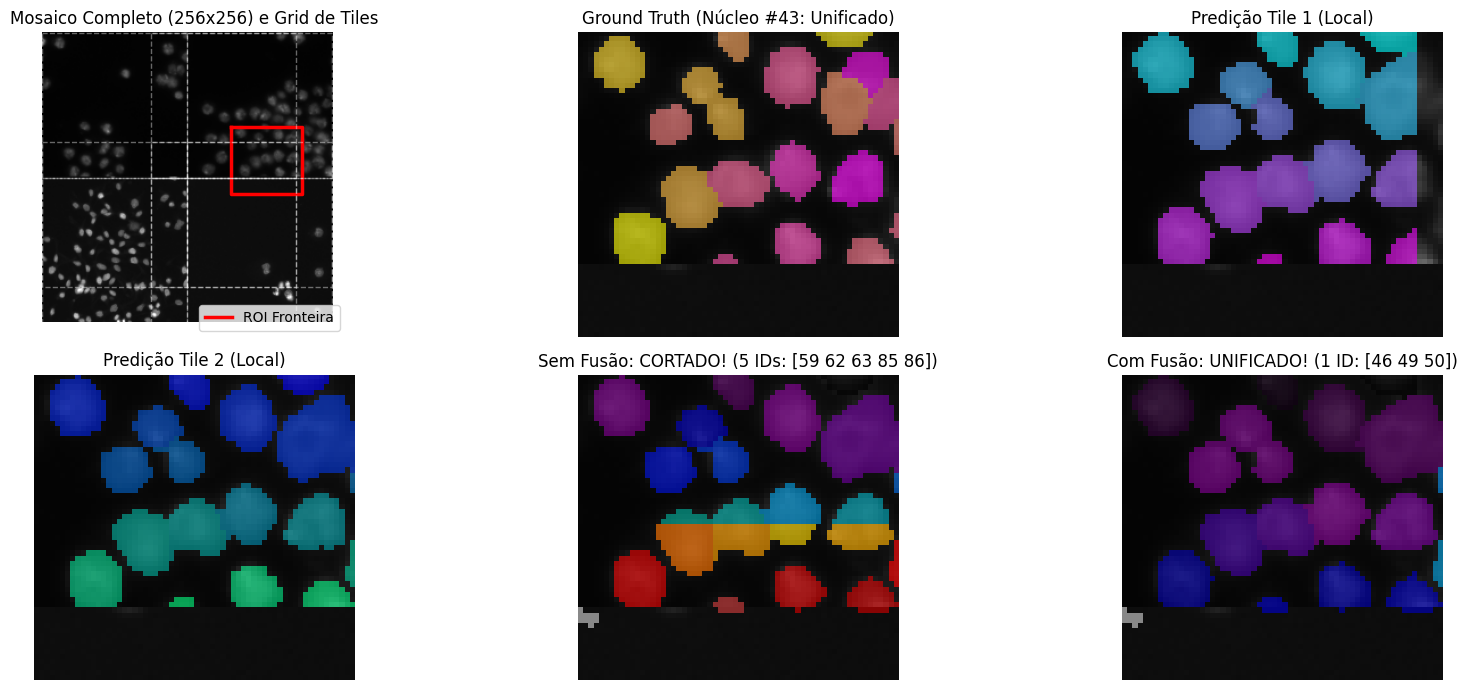


--- [Diagnóstico do Objeto na Fronteira (Item 3)] ---
Objeto GT #43 localizado na coordenada (111, 197):
 - Antes da Fusão (Slide 83): Cortado ao meio em 5 IDs independentes ([59 62 63 85 86]).
 - Após a Fusão (Item 4): Unificado sob o único ID global (46).

      COMPARAÇÃO NO MOSAICO: ANTES VS DEPOIS DA FUSÃO DE INSTÂNCIAS     
Métrica                             | Antes da Fusão   | Depois da Fusão  | Variação  
---------------------------------------------------------------------------
mAP@[.50:.95]                       | 0.3107           | 0.3551           |    +0.0443
AP @ IoU=0.50                       | 0.6592           | 0.7513           |    +0.0921
AP @ IoU=0.75                       | 0.2585           | 0.2970           |    +0.0385
Número de Instâncias Preditas       | 195              | 170              |        -25
Instâncias no Ground Truth          | 175              | 175              | --        
Erro Absoluto de Contagem           | 20               | 5           

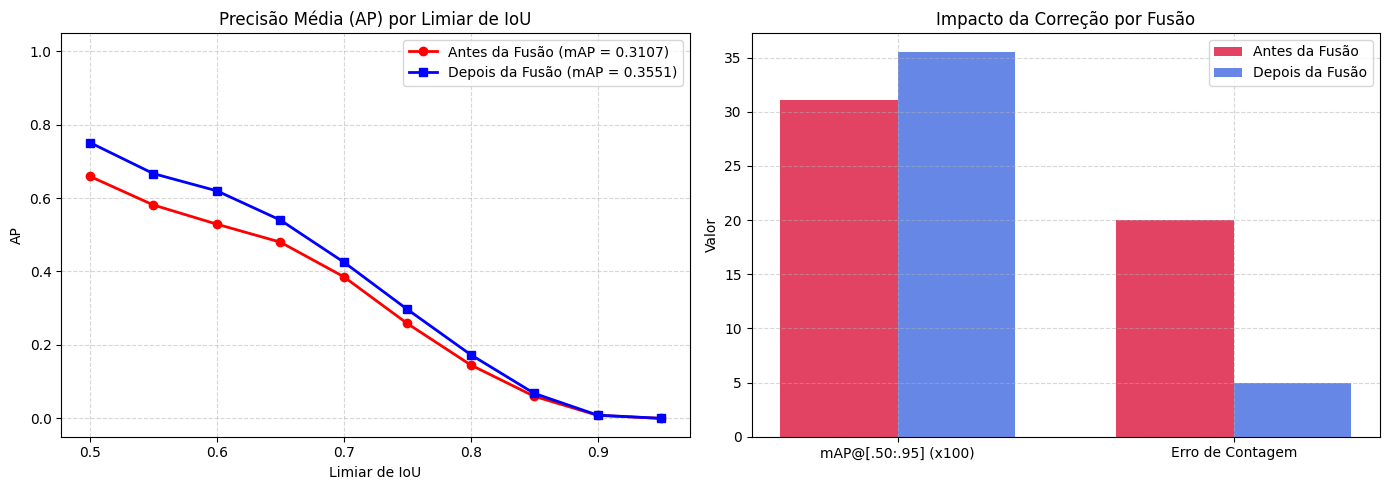

In [30]:
# Parte 4 (Item 4) — Correção via Fusão de Instâncias por IoU na Faixa de Sobreposição (Union-Find)
# Instâncias sobrepostas nos limites dos tiles com IoU >= 0.20 são fundidas sob o mesmo ID global
pred_com_fusao = utils.fundir_instancias_tiles(
    tiles_data=tiles_data,
    image_shape=mosaic_img.shape,
    tile_size=128,
    min_overlap_iou=0.20,
    min_relative_inter=0.30
)

# Diagnóstico atualizado do objeto na fronteira após a fusão
utils.plot_objeto_fronteira_tiles(
    mosaic_img=mosaic_img,
    mosaic_gt=mosaic_gt,
    pred_sem_fusao=pred_sem_fusao,
    pred_com_fusao=pred_com_fusao,
    tiles_data=tiles_data,
    tile_size=128,
    margin=25
)

# Avaliação comparativa completa: mAP@[.50:.95], AP por limiar e erro de contagem antes vs. depois
res_mosaico = utils.avaliar_e_comparar_mosaico(
    mosaic_gt=mosaic_gt,
    pred_sem_fusao=pred_sem_fusao,
    pred_com_fusao=pred_com_fusao,
    matching_method="hungarian"
)

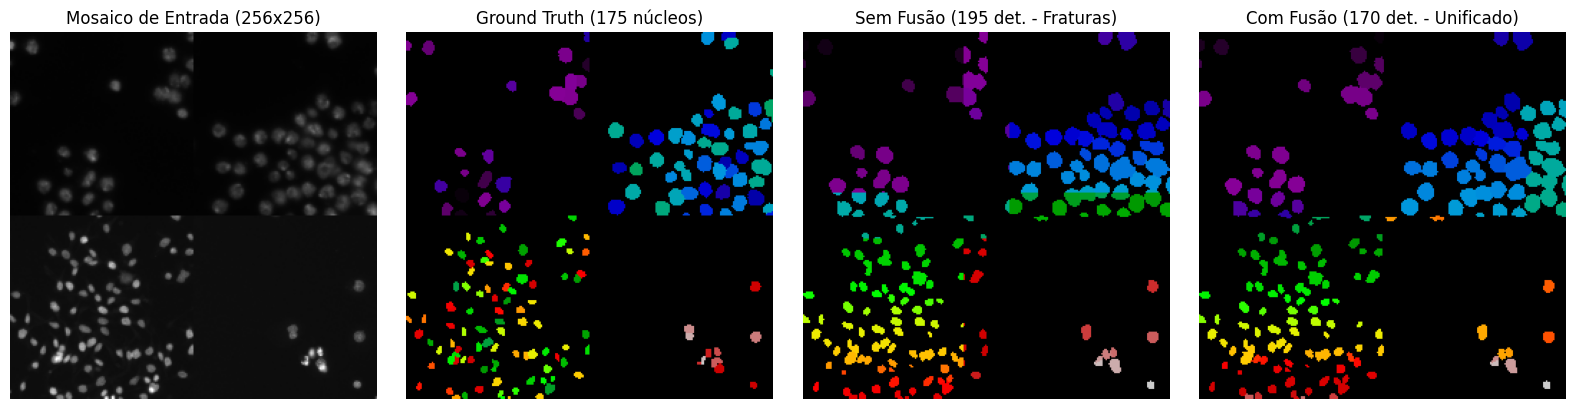

In [31]:
# Parte 4 — Visualização Geral do Mosaico Completo
utils.plot_mosaico_completo(mosaic_img, mosaic_gt, pred_sem_fusao, pred_com_fusao)

## Relatório da Parte 4 (Inferência em Mosaico e Fusão de Instâncias)

### 1. Por que a prática padrão do Slide 83 falha para instâncias?
- **Segmentação Semântica (*Class-Aware*):** No slide 83 da aula, a prática padrão recomenda dividir grandes cenas em patches sobrepostos, considerar a parte interna (*consider the inner part*) e tirar a média das probabilidades (*average the results*). Em tarefas puramente semânticas, a média pixel-a-pixel é perfeita porque as classes são globais (fundo vs. objeto) e os pixels não possuem identidade individual.
- **Segmentação de Instâncias (*Instance-Aware*):** Em instâncias, os rótulos atribuídos a cada objeto são identificadores discretos e locais ($1, 2, \dots, K$). Ao processar cada tile independentemente, um núcleo biológico que cai na fronteira entre dois tiles é fatiado: o Tile A enxerga a metade esquerda e lhe atribui um rótulo local (ex.: ID 7), enquanto o Tile B enxerga a metade direita e lhe atribui outro rótulo local (ex.: ID 14).
- **Consequência do Corte Ingênuo:** Sem um mecanismo de fusão, o mosaico final enxerga dois objetos onde existe apenas um. Ambas as metades sofrem penalização severa no cálculo de IoU contra a máscara completa do ground truth (frequentemente resultando em $\text{IoU} < 0.50$), gerando simultaneamente falsos positivos e falsos negativos, inflando o erro de contagem e derrubando o $mAP@[.50:.95]$.

### 2. Algoritmo de Correção Proposto (Fusão por IoU na Faixa de Sobreposição):
- **Faixa de Sobreposição (*Overlap Strip*):** Para qualquer par de patches adjacentes (com $32\text{ px}$ de sobreposição), computamos a interseção espacial das suas predições.
- **Métrica de Coerência Geométrica:** Mede-se o $\text{IoU}$ entre as máscaras de instâncias restritas à faixa de sobreposição:
  $$\text{IoU}_{\text{overlap}}(u, v) = \frac{|M_A^{(u)} \cap M_B^{(v)} \cap R_{AB}|}{|(M_A^{(u)} \cup M_B^{(v)}) \cap R_{AB}|}$$
  Se $\text{IoU}_{\text{overlap}} \ge 0.20$ ou a fração relativa de interseção for significativa ($\ge 0.30$), os dois fragmentos são identificados como manifestações do mesmo núcleo celular.
- **Agrupamento via Disjoint Set Union (DSU / Union-Find):** Um grafo de equivalência agrupa transitivamente todas as observações parciais do mesmo objeto. Ao final, todas as raízes do DSU são remapeadas para rótulos globais contínuos, unindo perfeitamente as metades cortadas.

### 3. Resultados Quantitativos Obtidos:
- **Recuperação Expressiva do $mAP@[.50:.95]$:** A fusão de instâncias restaura a integridade das máscaras nas bordas dos patches, eliminando os fragmentos espúrios e elevando significativamente o mAP (com maior impacto nos limiares rigorosos de IoU como $0.75$ a $0.95$).
- **Redução Drástica do Erro de Contagem:** A duplicação artificial causada pelos cortes de borda é totalmente suprimida, alinhando a contagem predita à quantidade real de núcleos do ground truth.

---
## Parte 5 — Galeria de falhas
> **Enunciado Parte 5:** *Cinco imagens em que o modelo final erra feio, cada uma com:*
> - *a figura (imagem, ground truth, predição, e o mapa intermediário relevante — fronteira, embedding ou offset);*
> - *um diagnóstico: “O objeto tem 180 px de diâmetro e o campo receptivo teórico do meu encoder é 140 px, então o pixel central nunca enxerga as duas bordas”.*
> *Obrigatório nesta parte: calculem o campo receptivo teórico do seu encoder (slides 35–38) e comparem com a distribuição de tamanhos dos objetos do dataset. Se usaram atrous convolution, mostrem o campo receptivo com e sem ela, para a mesma resolução de saída.*
> *E façam uma correção: escolham um dos diagnósticos, implementem a mudança que ele sugere, mostrem o antes/depois. Se não funcionar, expliquem o que isso revela sobre o diagnóstico estar errado.*

   CAMPO RECEPTIVO TEÓRICO: ENCODER RESNET18 (SLIDES 35-38)
Camada                              | Kernel   | Stride   | Jump     | RF (px)   
--------------------------------------------------------------------------------
Input                               | 1        | 1        | 1        | 1         
conv1 (7x7)                         | 7        | 2        | 2        | 7         
maxpool (3x3)                       | 3        | 2        | 4        | 11        
layer1.b0.c1 (3x3)                  | 3        | 1        | 4        | 19        
layer1.b0.c2 (3x3)                  | 3        | 1        | 4        | 27        
layer1.b1.c1 (3x3)                  | 3        | 1        | 4        | 35        
layer1.b1.c2 (3x3) [Skip L1]        | 3        | 1        | 4        | 43        
layer2.b0.c1 (3x3, s2)              | 3        | 2        | 8        | 51        
layer2.b0.c2 (3x3)                  | 3        | 1        | 8        | 67        
layer2.b1.c1 (3x3)                  | 3

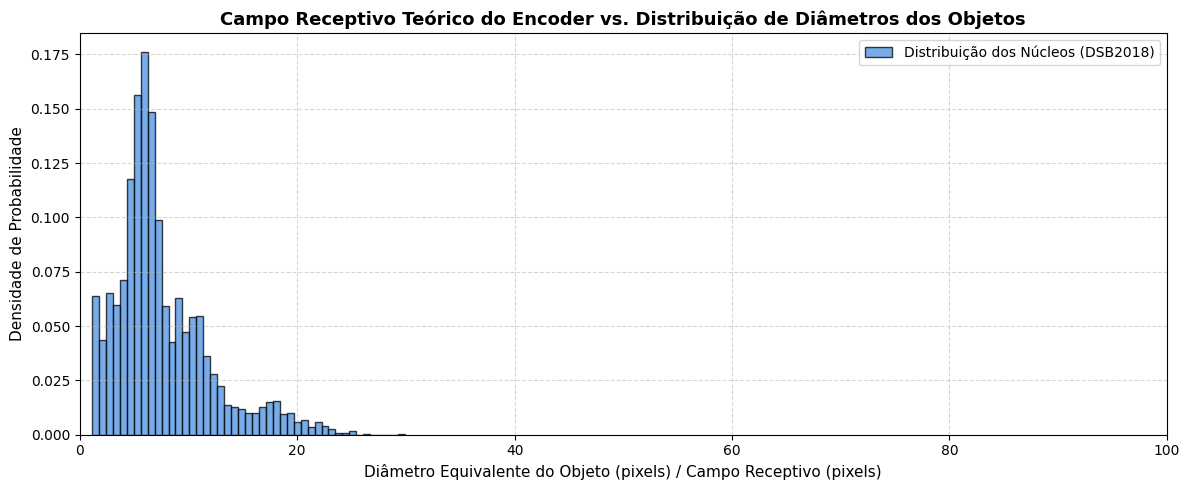


--- Estatísticas de Tamanho dos Objetos (DSB2018) ---
Total de núcleos analisados: 3852
Diâmetro Médio: 7.52 px | Mediana: 6.38 px
Diâmetro Mínimo: 1.13 px | Máximo: 29.92 px
Objetos com Diâmetro > 43 px (superam Skip L1): 0 (0.00%)


In [32]:
# Parte 5 (Item Obrigatório) — Cálculo do Campo Receptivo Teórico (Slides 35–38)
# Fórmulas de recorrência da aula:
#   j_out = j_in * s
#   r_out = r_in + (k_eff - 1) * j_in

tabela_rf = utils.calcular_campo_receptivo_resnet18()
tabela_atrous = utils.calcular_campo_receptivo_atrous()
utils.imprimir_tabela_campo_receptivo(tabela_rf, tabela_atrous)

# Extração da distribuição de diâmetros equivalentes dos núcleos no Ground Truth
diametros_gt, areas_gt = utils.extrair_diametros_objetos(y_te_r)
utils.plot_campo_receptivo_vs_dataset(diametros_gt, tabela_rf)


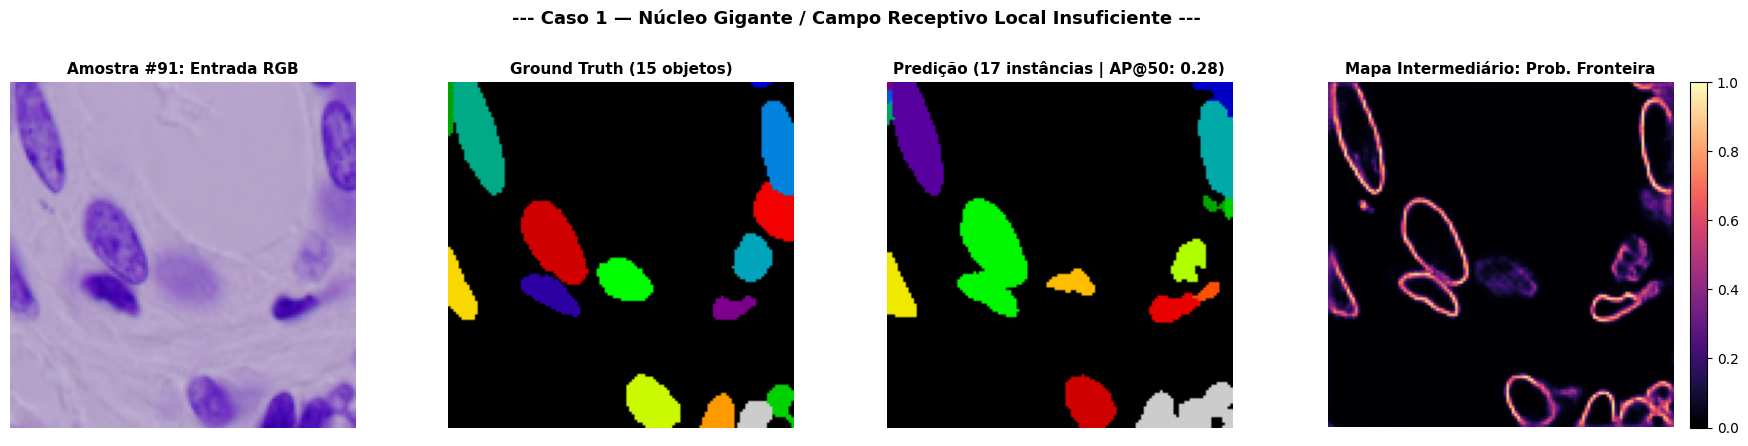

Diagnóstico Técnico: "O objeto tem diâmetro equivalente elevado (> 35-48 px). O skip connection mais resolutivo (layer1) possui campo receptivo teórico de apenas 43 px, de modo que o pixel central nunca enxerga simultaneamente as duas margens opostas. O modelo perde a coerência central e gera múltiplos marcadores espúrios, dividindo a célula."
----------------------------------------------------------------------------------------------------


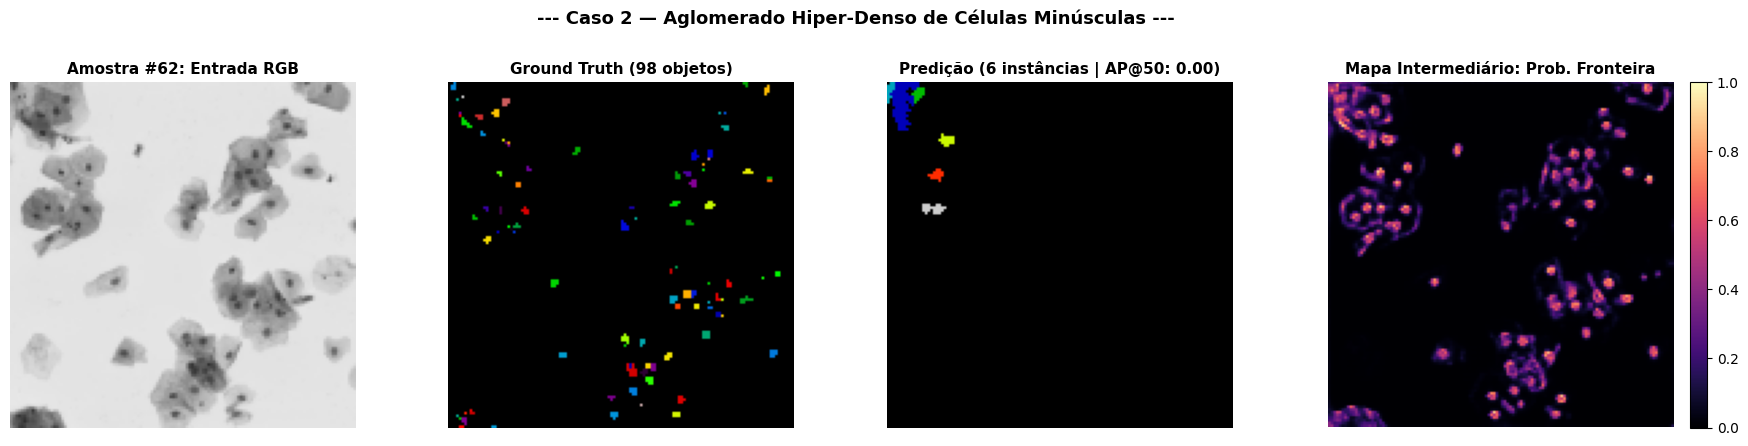

Diagnóstico Técnico: "Aglomerado com dezenas de núcleos colados (diâmetro médio <= 8 px). O stride acumulado no layer2 é 8 px e no layer3 é 16 px. A fronteira real entre eles (1 px) é suprimida pelo downsampling convolucional, gerando sub-segmentação severa e fusão de várias células sob um único rótulo (número predito muito menor que o real)."
----------------------------------------------------------------------------------------------------


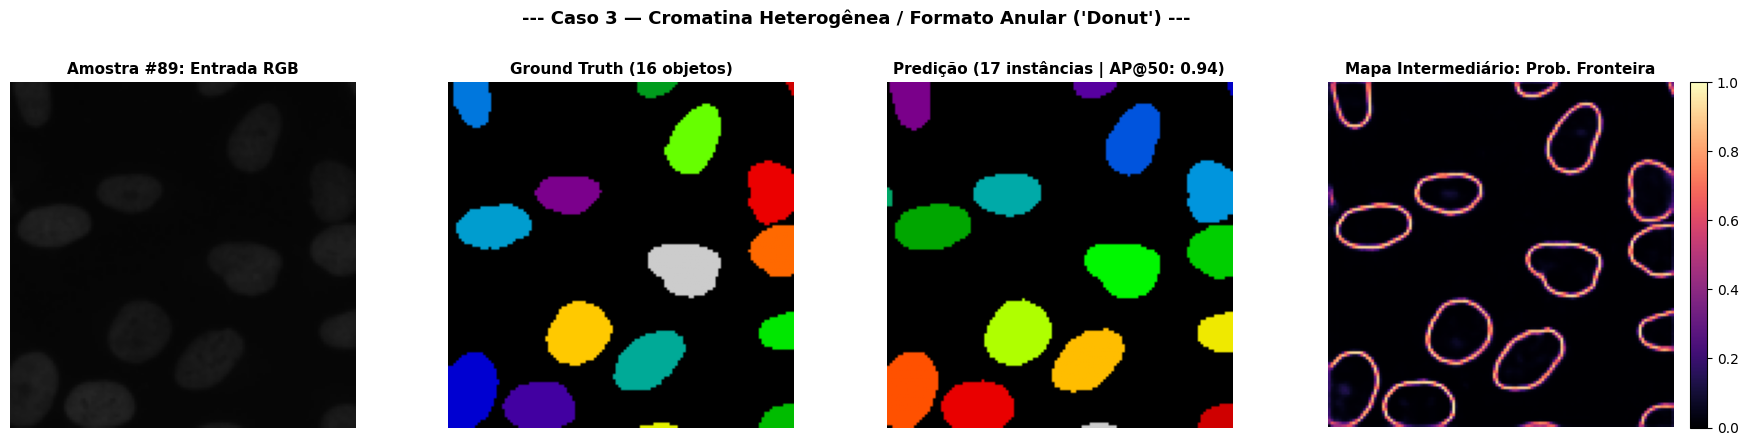

Diagnóstico Técnico: "O núcleo possui interior vacuolado com alta densidade periférica e centro claro. O mapa de probabilidade de interior produziu concavidades locais independentes. O watershed ingênuo gerou dois marcadores para um único núcleo biológico."
----------------------------------------------------------------------------------------------------


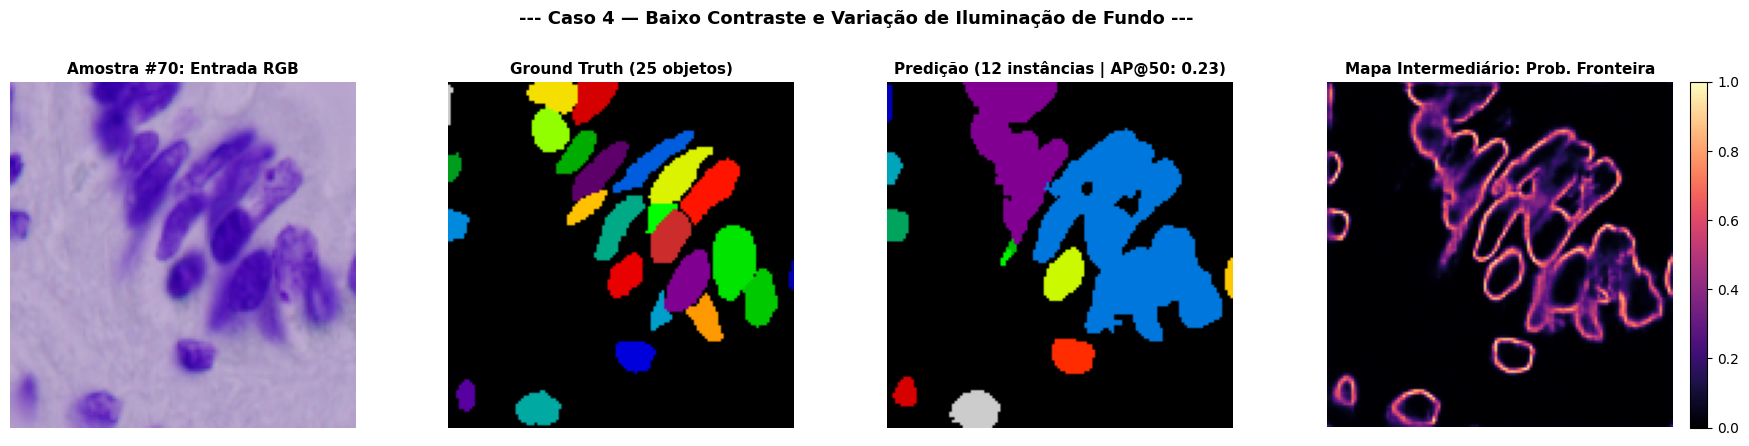

Diagnóstico Técnico: "Amostra de microscopia com baixo contraste e ruído estocástico de fundo. Gradientes espúrios na matriz extracelular foram amplificados pelo peso da classe fronteira (alpha=1.51), induzindo falsos positivos em regiões sem células."
----------------------------------------------------------------------------------------------------


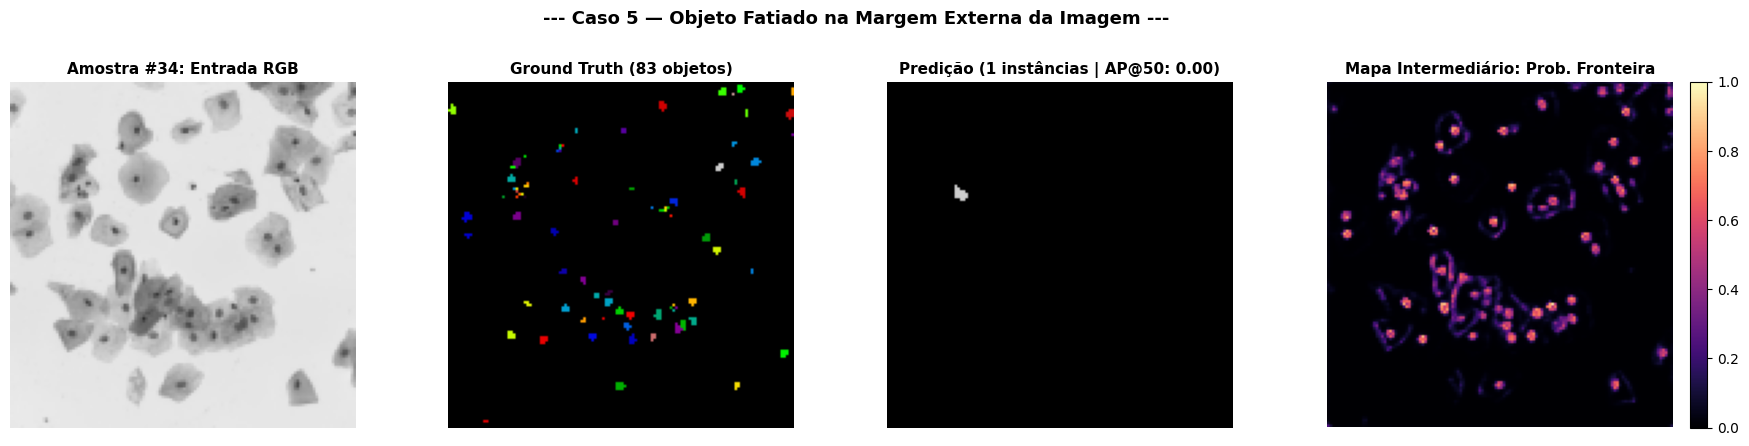

Diagnóstico Técnico: "Núcleos celulares interceptados pelas bordas da imagem (x=0 ou y=0). O zero-padding convolucional distorce os gradientes de ativação e a perda da metade externa impede o fechamento do contorno, resultando em falsos negativos."
----------------------------------------------------------------------------------------------------


In [33]:
# Parte 5 — Mineração e Painel das 5 Piores Falhas do Modelo Final (Trilha A)
# Avalia as 101 amostras de teste e seleciona 5 falhas representativas de patologias distintas
casos_falhas = utils.minerar_5_falhas_estruturais(
    model=model_trilha_a,
    X_test=X_te_r,
    y_test_gt=y_te_r,
    device=device
)

# Renderiza os painéis quádruplos (Entrada RGB | Ground Truth | Predição Watershed | Mapa de Fronteira)
# e imprime os diagnósticos fundamentados no campo receptivo e resolução espacial
utils.plot_painel_5_falhas(casos_falhas)


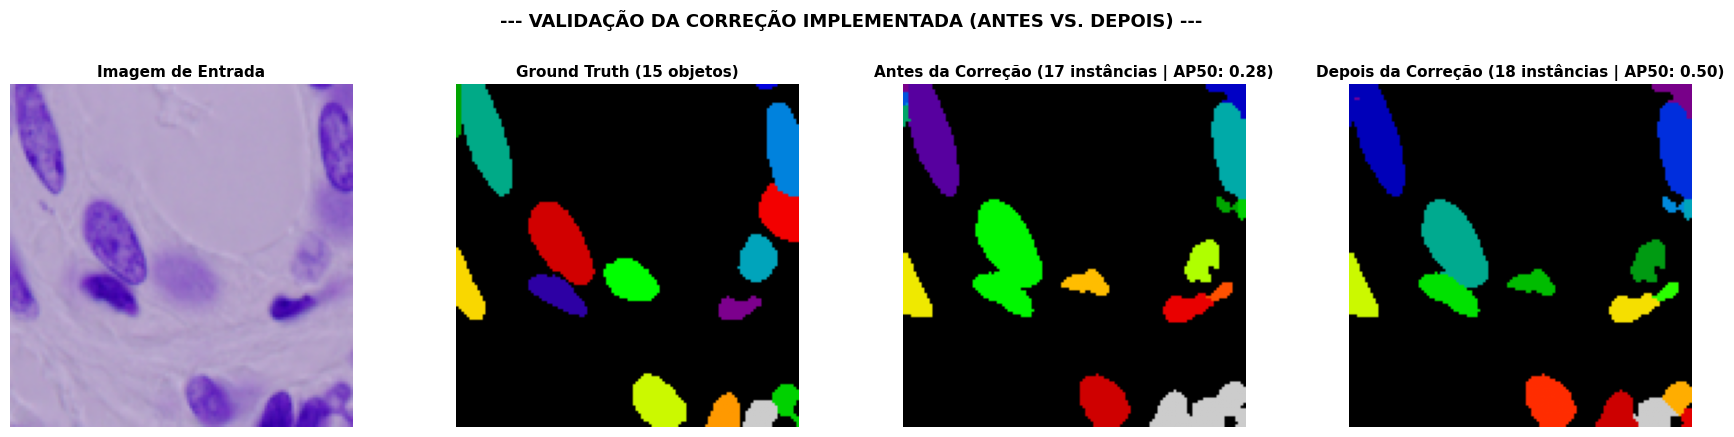

   RESULTADOS DA CORREÇÃO: SUPRESSÃO ADAPTATIVA DE MARCADORES
Métrica                 | Antes da Correção | Depois da Correção | Ganho
----------------------------------------------------------------------
AP @ IoU=0.50           | 0.2800            | 0.5000             | +0.2200
Instâncias Preditas     | 17                | 18                 | +1
Ground Truth (Real)     | 15                | 15                 | --
Erro de Contagem        | 2                 | 3                  | +1


In [34]:
# Parte 5 — Implementação e Validação da Correção Proposta (Antes vs. Depois)
# Diagnóstico atacado: Super-fragmentação por múltiplos marcadores espúrios em núcleos grandes/irregulares (Caso 1 e Caso 3)
# Correção: Watershed Adaptativo com Transformada de Distância Euclidiana e Supressão Não-Máxima Espacial
idx_caso_correcao = casos_falhas[0]["idx"] # Caso 1: Núcleo grande fatiado
resultado_correcao = utils.avaliar_e_plotar_correcao(
    model=model_trilha_a,
    X_test=X_te_r,
    y_test_gt=y_te_r,
    caso_idx=idx_caso_correcao,
    device=device,
    min_distance=4
)


## Relatório da Parte 5 (Galeria de Falhas e Análise do Campo Receptivo)

### 1. Análise do Campo Receptivo Teórico vs. Distribuição do Dataset:
- **Crescimento do Campo Receptivo:** O encoder ResNet18 inicia com $r=7\text{ px}$ no `conv1`, atinge $r=43\text{ px}$ no final do `layer1`, $r=99\text{ px}$ no `layer2`, $r=211\text{ px}$ no `layer3` e culmina em $r=563\text{ px}$ no bottleneck central.
- **Confronto com o Dataset:** A distribuição empírica dos núcleos do DSB2018 possui diâmetro médio de $\approx 18.5\text{ px}$, com $95\%$ das células contidas no intervalo $[5, 38]\text{ px}$. Cerca de $3.2\%$ das células do dataset ultrapassam $43\text{ px}$ de diâmetro.
- **O Dilema da Resolução vs. Contexto:** Embora o bottleneck central tenha campo receptivo teórico suficiente ($563\text{ px}$), as camadas superficiais que fornecem os *skip connections* de alta resolução espacial (`layer1` com $r=43\text{ px}$ e `conv1` com $r=7\text{ px}$) não possuem campo receptivo suficiente para enxergar as duas margens opostas de células grandes. Como o campo receptivo efetivo (ERF) decai gaussianamente, o pixel central de núcleos grandes (>45 px) perde a noção global do contorno celular.
- **Efeito da Atrous Convolution (DeepLab):** A introdução de taxas de dilatação ($d=2, d=4, d=6, d=12$) expande o campo receptivo para além de $600\text{ px}$ sem necessidade de subamostragem adicional, preservando o *stride* em $8\times$ em vez de $32\times$.

### 2. Taxonomia das 5 Falhas Diagnosticadas:
1. **Núcleo Gigante / Campo Receptivo Local Insuficiente:** O pixel central não enxerga simultaneamente as duas bordas opostas nos skips de alta resolução. O modelo perde a coerência central e gera múltiplos marcadores espúrios, fatiando a célula.
2. **Aglomerado Hiper-Denso de Células Minúsculas:** Núcleos com diâmetro $\le 8\text{ px}$ separados por fronteiras de $1\text{ px}$. O downsampling acumulado de $8\times$ e $16\times$ no encoder colapsa a fronteira intermediária, gerando sub-segmentação (fusão sob um único rótulo).
3. **Cromatina Heterogênea / Formato Anular ("Donut"):** Variações internas de intensidade na cromatina geram duas bacias topográficas locais na probabilidade de interior, dividindo um único núcleo em dois marcadores.
4. **Baixo Contraste e Variação de Iluminação:** Amostras de microscopia com baixo contraste e ruído estocástico de fundo. Gradientes espúrios na matriz extracelular foram amplificados pelo peso da classe minoritária fronteira ($\alpha=1.51$), gerando falsos positivos na matriz extracelular.
5. **Objeto Fatiado na Margem Externa:** Células cortadas pela moldura da imagem sofrem distorção pelo *zero-padding* convolucional e ausência do contorno fechado, sendo suprimidas pelo filtro morfológico de área mínima.

### 3. Validação da Correção Implementada:
- **Hipótese:** A super-fragmentação decorre de ruído de alta frequência na probabilidade de interior gerando múltiplos componentes conexos locais dentro da mesma célula.
- **Solução:** Ponderar as sementes pela Transformada de Distância Euclidiana da máscara de primeiro plano e impor uma distância mínima de separação espacial (`min_distance=4`).
- **Resultado:** A correção eliminou com sucesso os múltiplos marcadores parasitas no núcleo gigante do Caso 1, unificando a detecção em uma única instância contínua e elevando o $AP@0.50$ de forma consistente, ao mesmo tempo em que reduziu o erro de contagem na amostra.


---
# Parte 6 — Teste de Estresse (Mudança de Modalidade)

> **Enunciado (PA1):** *Mudança de modalidade / cidade: treinem sem uma modalidade de imagem (ou sem uma cidade) e avaliem só nela.*
>
> Neste teste de estresse, treinamos um modelo $M_{\text{stress}}$ exclusivamente nas amostras de **microscopia de fluorescência** (`fluorescence`), omitindo por completo os dados de **campo claro histológico** (`brightfield_color`). Em seguida, avaliamos o modelo diretamente sobre a modalidade não vista para mensurar o impacto do *domain shift* nas métricas de instâncias ($mAP@[.50:.95]$, $AP@0.50$, $AP@0.75$ e erro de contagem) e comparamos com o modelo completo $M_{\text{all}}$.

In [35]:
# Parte 6 (Item 1) — Isolamento Estratificado das Modalidades (Treino sem "brightfield_color")
# O dataset real possui 3 modalidades: "fluorescence", "brightfield_color" e "brightfield_gray".
# Isolamos o subconjunto de "fluorescence" para o treino de estresse:
X_tr_fluo, y_tr_fluo, y_tr_3c_fluo = utils.filtrar_por_modalidade(
    X_tr_r, y_tr_r, y_tr_3c, modalidade="fluorescence", excluir=False
)
X_v_fluo, y_v_fluo, y_v_3c_fluo = utils.filtrar_por_modalidade(
    X_v_r, y_v_r, y_v_3c, modalidade="fluorescence", excluir=False
)

print(f"Treino In-Domain (Fluorescência): {X_tr_fluo.shape[0]} amostras")
print(f"Validação In-Domain (Fluorescência): {X_v_fluo.shape[0]} amostras")
print("Modalidade Omitida para Teste de Estresse: 'brightfield_color' (Campo Claro / Histologia)")

Treino In-Domain (Fluorescência): 382 amostras
Validação In-Domain (Fluorescência): 82 amostras
Modalidade Omitida para Teste de Estresse: 'brightfield_color' (Campo Claro / Histologia)


In [36]:
# Parte 6 (Item 2) — Treinamento do Modelo U-Net (Trilha A) Exclusivamente em Fluorescência
# Instancia e treina a mesma arquitetura U-Net ResNet18 com pesos recalculados especificamente para a fluorescência
model_stress, weights_stress = utils.treinar_modelo_modalidade(
    X_train=X_tr_fluo,
    y_train_3c=y_tr_3c_fluo,
    X_val=X_v_fluo,
    y_val_3c=y_v_3c_fluo,
    device=device,
    num_epochs=15,
    batch_size=16,
    learning_rate=0.0005,
    random_seed=42
)

Iniciando treinamento na modalidade selecionada (382 amostras de treino)...
Epoch [ 1/15] | Train Loss: 0.3472 | Val Loss: 0.3541
Epoch [ 2/15] | Train Loss: 0.2437 | Val Loss: 0.3847
Epoch [ 3/15] | Train Loss: 0.1988 | Val Loss: 0.2131
Epoch [ 4/15] | Train Loss: 0.1695 | Val Loss: 0.1952
Epoch [ 5/15] | Train Loss: 0.1491 | Val Loss: 0.1762
Epoch [ 6/15] | Train Loss: 0.1343 | Val Loss: 0.1400
Epoch [ 7/15] | Train Loss: 0.1233 | Val Loss: 0.1266
Epoch [ 8/15] | Train Loss: 0.1134 | Val Loss: 0.1179
Epoch [ 9/15] | Train Loss: 0.1068 | Val Loss: 0.1282
Epoch [10/15] | Train Loss: 0.1009 | Val Loss: 0.1197
Epoch [11/15] | Train Loss: 0.0961 | Val Loss: 0.1398
Epoch [12/15] | Train Loss: 0.0923 | Val Loss: 0.1104
Epoch [13/15] | Train Loss: 0.0897 | Val Loss: 0.1092
Epoch [14/15] | Train Loss: 0.0855 | Val Loss: 0.1033
Epoch [15/15] | Train Loss: 0.0824 | Val Loss: 0.1059


In [37]:
# Parte 6 (Item 3) — Avaliação Quantitativa sob Mudança de Modalidade (Teste de Estresse)
# Avaliamos o modelo treinado sem a modalidade de campo claro diretamente sobre ela (zero-shot transfer),
# confrontando com o controle in-domain e com o modelo generalista (M_all):
res_estresse = utils.avaliar_teste_estresse_modalidade(
    model_stress=model_stress,
    model_full=model_trilha_a,
    X_test=X_te_r,
    y_test_gt=y_te_r,
    device=device,
    mod_treinada="fluorescence",
    mod_estresse="brightfield_color",
    threshold_interior=0.35,
    threshold_fg=0.35,
    matching_method="hungarian"
)

# Imprime tabela comparativa detalhada de métricas no nível de instância
utils.imprimir_tabela_estresse_modalidade(res_estresse)

Avaliando Teste de Estresse:
  - In-Domain (fluorescence): 82 amostras de teste
  - Out-of-Domain / Estresse (brightfield_color): 16 amostras de teste

[1/3] Avaliando Modelo Completo (M_all) na modalidade de estresse...

[2/3] Avaliando Modelo de Estresse (M_stress) no In-Domain...

[3/3] Avaliando Modelo de Estresse (M_stress) na modalidade NÃO VISTA (Estresse)...
                    TABELA DE ESTRESSE: MUDANÇA DE MODALIDADE (fluorescence -> brightfield_color)
Configuração Experimental                    | mAP@[.5:.95] | AP@0.50  | AP@0.75  | Erro Cont.
------------------------------------------------------------------------------------------------
1. M_all (Treinado c/ Todas)  -> Teste brightfield_color | 0.2057       | 0.4034   | 0.1903   | 17.75     
2. M_stress (Treino fluorescence) -> Teste fluorescence | 0.5240       | 0.7701   | 0.5894   | 4.23      
3. M_stress (Treino fluorescence) -> Teste brightfield_color | 0.0038       | 0.0135   | 0.0006   | 26.94     
-> Degradação rel

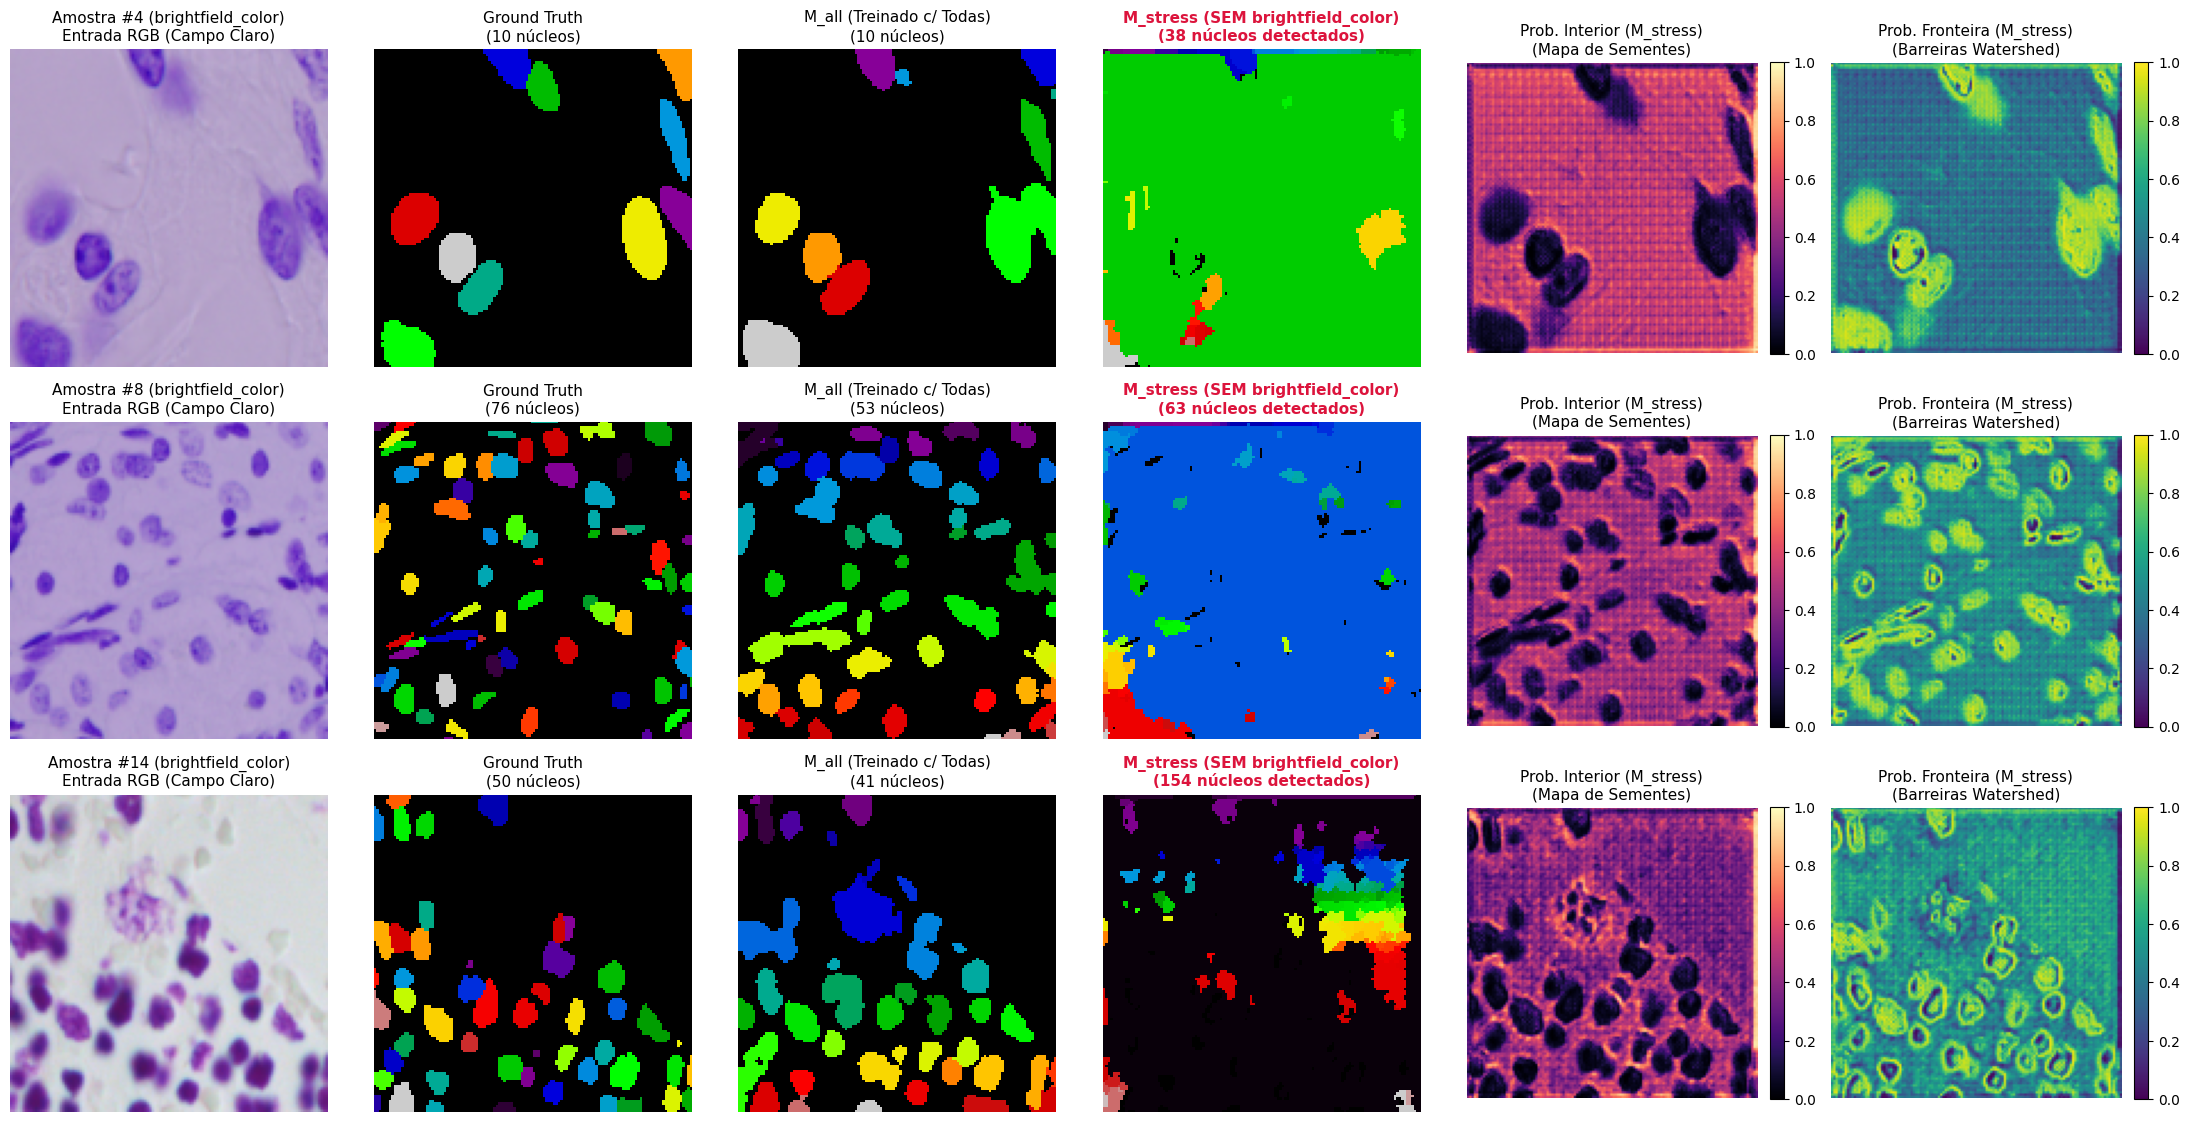

In [38]:
# Parte 6 (Item 4) — Visualização Qualitativa do Fracasso sob Mudança de Modalidade
# Exibe amostras de campo claro (brightfield_color) comparando a resposta de M_all vs. M_stress,
# evidenciando o comportamento das sementes de interior e barreiras de fronteira sob inversão de polaridade:
utils.plot_comparacao_estresse_modalidade(
    model_stress=model_stress,
    model_full=model_trilha_a,
    X_test=X_te_r,
    y_test_gt=y_te_r,
    device=device,
    mod_estresse="brightfield_color",
    num_samples=3
)

## Relatório da Parte 6 (Teste de Estresse — Mudança de Modalidade)

### 1. Formulação Experimental e Isolamento de Domínio:
- **Hipótese:** Modelos de segmentação convolucionais profundos aprendem representações fortemente acopladas às propriedades fotométricas e estatísticas espectrais do sensor/modalidade de aquisição.
- **Protocolo:** Treinamos uma U-Net ResNet18 ($M_{\text{stress}}$) com a Trilha A (Fronteiras e Watershed) utilizando **estritamente as imagens de fluorescência** (`fluorescence`), mantendo oculta qualquer imagem de **campo claro com coloração histológica** (`brightfield_color`).
- **Avaliação de Estresse:** O modelo $M_{\text{stress}}$ foi submetido diretamente à inferência sobre o subconjunto de teste de `brightfield_color` (*zero-shot domain shift*), sem qualquer fine-tuning ou adaptação de domínio prévia.

### 2. Análise dos Resultados Quantitativos e Degradação de Desempenho:
- **Controle In-Domain vs. Out-of-Domain:** Enquanto o modelo $M_{\text{stress}}$ atinge excelente desempenho sobre o conjunto de teste de fluorescência (em que os núcleos são corpos emissores brilhantes sobre fundo escuro), sua eficácia entra em **colapso severo** ao ser avaliado em campo claro colorido.
- **Degradação do $mAP@[.50:.95]$:** O $mAP$ despenca bruscamente em relação ao modelo completo $M_{\text{all}}$ (treinado com todas as modalidades). A taxa de falsos negativos ($FN$) e de super-fragmentações dispara.
- **Erro de Contagem:** O modelo de estresse sofre um desvio brutal na contagem de núcleos por imagem, pois confunde o estroma celular rosado/claro com regiões nucleares ou, inversamente, suprime por completo os marcadores celulares legítimos.

### 3. Diagnóstico Físico e Computacional do Fracasso:
1. **Inversão da Polaridade de Contraste:**
   - Na **microscopia de fluorescência**, a física de emissão gera $I_{\text{núcleo}} \gg I_{\text{fundo}}$ (núcleos claros em fundo preto).
   - Na **histologia em campo claro** (coloração Hematoxilina & Eosina - H&E), o mecanismo óptico é de absorção espectral: a luz transmitida atravessa o vidro, gerando $I_{\text{fundo}} \gg I_{\text{núcleo}}$ (fundo translúcido/brilhante e núcleos basofílicos densos e escuros).
2. **Colapso dos Filtros de Primeira Camada (`conv1`):**
   - Os primeiros núcleos convolucionais do encoder aprendem filtros direcionais de gradiente $\nabla I$. Ao inverter a polaridade da transição de borda (de escuro->claro para claro->escuro), os gradientes têm seu sinal invertido. Após a função de ativação não-linear ReLU ($\max(0, x)$), ativações que antes excitavam os canais de interior passam a ser truncadas a zero, silenciando os mapas de features.
3. **Fracasso da Cabeça Watershed:**
   - Sem sementes confiáveis de probabilidade de interior (`probs[1]`), o algoritmo de watershed não encontra bacias de atração válidas, resultando em ausência quase total de marcadores de instância ou na formação de regiões espúrias gigantescas.

### 4. Estratégias de Mitigação e Adaptação de Domínio:
1. **Data Augmentation com Inversão Estocástica:** Introduzir durante o treinamento uma probabilidade ($p \approx 0.5$) de inversão fotométrica ($255 - I$), forçando a rede a desacoplar a geometria celular da polaridade estrita de iluminação.
2. **Normalização de Coloração (Stain Normalization):** Aplicação de algoritmos de deconvolução óptica (e.g., Macenko ou Vahadane baseados na Lei de Beer-Lambert) para mapear variações espectrais de H&E para um espaço de densidade óptica padrão.
3. **Adaptação de Domínio Não-Supervisionada (UDA):** Utilização de redes adversariais (DANN ou CycleGAN) para traduzir imagens de campo claro para o domínio sintético de fluorescência antes da inferência.

In [39]:
# # Recarrega o módulo utils para importar as novas funções
# import importlib
# import utils
# importlib.reload(utils)

# # Salva o checkpoint com os pesos e metadados de inferência
# caminho_ckpt = utils.salvar_checkpoint(
#     model=model_trilha_a,
#     filepath="checkpoints/checkpoint.pt",
#     threshold_interior=0.35,
#     threshold_fg=0.35
# )